In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import pingouin as pg

In [2]:
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap, to_hex
from matplotlib.ticker import FormatStrFormatter

In [3]:
from jupyter_utils import add_grey

In [4]:
import statsmodels.api as sm

In [5]:
sns.set_style("ticks")

In [6]:
# warnings.simplefilter("ignore")
warnings.filterwarnings('ignore', r'All-NaN (slice|axis) encountered')

In [7]:
PATH = '/Users/galina.ryazanskaya/Downloads/thesis?/code?/processed_values/'

In [8]:
PATH_FIG = '/Users/galina.ryazanskaya/Downloads/thesis?/figures/'

In [9]:
long_df_ru = pd.read_csv(PATH + 'long_ru_sz_dep_95_multi_rekeyed_r_adj.csv', index_col=0)
long_df_ru['unikey'] = long_df_ru["scale"] + "_" + long_df_ru["performance_metric"] + "_" + long_df_ru["predictor_varset"]

In [10]:
long_df_ru_ps_only = long_df_ru[long_df_ru['subset'] == 'psychosis_only']

In [11]:
long_df_ru_dep_only = long_df_ru[long_df_ru['subset'] == 'depression_only']

In [12]:
long_df_de = pd.read_csv(PATH + 'long_de_95_multi_rekeyed_r_adj.csv', index_col=0)

In [13]:
long_df = pd.concat([long_df_ru_ps_only, long_df_de])
long_df.tail()

,lang,subset,task,scale,performance_metric,predictor_varset,metric_group,metric_name,group_pair,median,...,corr_mean_sent_len_CI_high,corr_n_sents_median,corr_n_sents_mean,corr_n_sents_CI_low,corr_n_sents_CI_high,corr_n_words_median,corr_n_words_mean,corr_n_words_CI_low,corr_n_words_CI_high,unikey
2875,de,NaN,sadness,multivariate,r2,dc_bv,overview,col_independent,NaN,0.226627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2876,de,NaN,sadness,multivariate,r2,dc,overview,col_independent,NaN,0.162010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2877,de,NaN,sadness,multivariate,llh,multi,overview,col_independent,NaN,0.537601,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2878,de,NaN,sadness,multivariate,llh,dc_bv,overview,col_independent,NaN,0.409773,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2879,de,NaN,sadness,multivariate,llh,dc,overview,col_independent,NaN,0.081603,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
long_df['unikey'] = long_df["scale"] + "_" + long_df["performance_metric"] + "_" + long_df["predictor_varset"]

In [15]:
long_df[long_df["scale"] == "multivariate"].performance_metric.unique()

array(['r2', 'llh'], dtype=object)

In [16]:
long_df.scale.unique()

array(['panss_pos', 'panss_neg', 'panss_o', 'panss_total', 'group_diff',
       'group_diff_sz_dep', 'group_diff_dep', 'multivariate',
       'saps_total', 'sans_total'], dtype=object)

In [17]:
long_df.performance_metric.unique()

array(['r', 'r2', 'r2_diff', 'r_marginal', 't', 'auc', 'llh', 'llh_diff',
       'llh_marginal_diff'], dtype=object)

In [18]:
long_df.group_pair.unique()

array([nan, 'control_sz', 'sz_dep', 'control_dep'], dtype=object)

In [19]:
long_df.predictor_varset.unique()

array(['single', 'dc_bv_m', 'multi', 'dc_bv', 'dc'], dtype=object)

In [20]:
P_LLR = 3.84

## Assign colors to metrics

fix metric colors - dict (color by group)  \
fix metric order

In [21]:
metric_groups = {group: long_df[long_df['metric_group'] == group]['metric_name'].unique().tolist() for group in long_df['metric_group'].unique()}

In [22]:
# {x: x.replace('_', ' ') for x in long_df['metric_name'].unique()}

In [23]:
name_map = {'bert_cgcoh': 'BERT cgcoh',
 'bert_gcoh': 'BERT gcoh',
 'bert_lcoh': 'BERT lcoh',
 'bert_pppl': 'BERT pppl',
 'bert_scoh': 'BERT scoh',
 'bert_sprob': 'BERT sprob',
 'glove_avg_cgcoh': 'GloVe mean cgcoh',
 'glove_avg_gcoh': 'GloVe mean gcoh',
 'glove_avg_lcoh': 'GloVe mean lcoh',
 'glove_avg_scoh': 'GloVe mean scoh',
 'glove_tf_cgcoh': 'GloVe tf cgcoh',
 'glove_tf_gcoh': 'GloVe tf gcoh',
 'glove_tf_lcoh': 'GloVe tf lcoh',
 'glove_tf_scoh': 'GloVe tf scoh',
 'w2v_avg_cgcoh': 'w2v mean cgcoh',
 'w2v_avg_gcoh': 'w2v mean gcoh',
 'w2v_avg_lcoh': 'w2v mean lcoh',
 'w2v_avg_scoh': 'w2v mean scoh',
 'w2v_tf_cgcoh': 'w2v tf cgcoh',
 'w2v_tf_gcoh': 'w2v tf gcoh',
 'w2v_tf_lcoh': 'w2v tf lcoh',
 'w2v_tf_scoh': 'w2v tf scoh',
 'L1': 'loops of size 1',
 'L2': 'loops of size 2',
 'L3': 'loops of size 3',
 'LCC': 'LCC',
 'LSC': 'LSC',
 'PE': 'parallel edges',
 'degree_average': 'degree mean',
 'degree_std': 'degree std',
 'number_of_edges': 'number of edges',
 'number_of_nodes': 'number of nodes',
 'LTR': 'LTR',
 'MALTR': 'MALTR',
 'n_words': 'word count',
 'ADJ': 'POS rate: ADJ',
 'ADV': 'POS rate: ADV',
 'AUX': 'POS rate: AUX',
 'CCONJ': 'POS rate: CCONJ',
 'DET': 'POS rate: DET',
 'NOUN': 'POS rate: NOUN',
 'PART': 'POS rate: PART',
 'PRON': 'POS rate: PRON',
 'PROPN': 'POS rate: PROPN',
 'SCONJ': 'POS rate: SCONJ',
 'VERB': 'POS rate: VERB',
 'max_sent_len': 'max sent len',
 'mean_sent_len': 'mean sent len',
 'min_sent_len': 'min sent len',
 'n_sents': 'sent count',
 'std_sent_len': 'std sent len'}

In [24]:
overview_model_to_name = {
    "multi": "multivariate model",
    "dc": "major covariates"
}

In [25]:
LM_groups_metrics = {}
LM_groups_models = {}
for metric_name in metric_groups['LM']:
    model, metric = metric_name.rsplit('_', 1)
    LM_groups_metrics.setdefault(metric, []).append(metric_name)
    LM_groups_models.setdefault(model, []).append(metric_name)

In [26]:
group_to_color = {'graph': '#AD2070', #"#fbacb9", # '#ad017e', 
                  'lexical': '#A29CE4', 
                  'syntactic': '#FD9341', 
                  'LM': "#4D7E80"}
group_to_palette = {'graph': 'RdPu', 'lexical': 'Purples', 'syntactic': 'YlOrRd'}

In [27]:
model_to_color = {'bert': '#3b6a2a', 'glove_avg': '#1d5b5d', 'glove_tf': '#274754', 'w2v_avg': '#0c2c41', 'w2v_tf': '#1d3658'}

In [28]:
best_verbosity_metric_map = {
    'de': ('syntactic', 'mean_sent_len'),
    'ru': ('lexical', 'n_words')
}

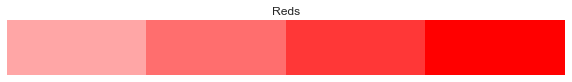

In [29]:
def sample_categorical_palette(color_name, size, cmap=None, low=0.35):
    """
    Samples evenly from a continuous colormap ranging from light-shade to a full color,
    to create a categorical palette.
    
    Parameters:
    - color_name (str): Name of the target color (e.g., "blue", "red", "#ff5733").
    - size (int): Number of discrete colors in the resulting categorical palette.
    
    Returns:
    - list: A list of RGB tuples representing the categorical palette.
    """
    # Get the colormap
    if not cmap:
        cmap = LinearSegmentedColormap.from_list("custom_colormap", ["white", color_name])
    
    # Sample evenly spaced values between low and 1
    colors = [cmap(i) for i in np.linspace(low, 1, size)]
    
    return colors

# Visualize the sampled palette
def visualise_palette(palette, title):
    plt.figure(figsize=(10, 1))
    plt.imshow([palette], aspect="auto")
    plt.axis("off")
    plt.title(title)
    plt.show()

# Example usage:
categorical_palette = sample_categorical_palette('red', 4)
visualise_palette(categorical_palette, 'Reds')

In [30]:
metric_to_color = {}
for group in metric_groups:
    if group == 'overview':
        continue
    if group == 'LM':
        for model in LM_groups_models:
            tgt_color = model_to_color[model]
            tgt_len = len(LM_groups_models[model])
            palette = sample_categorical_palette(tgt_color, tgt_len)
            # visualise_palette(palette, model)
            for i, metric in enumerate(LM_groups_models[model]):
                metric_to_color[metric] = to_hex(palette[i])
    else:
        tgt_plt = group_to_palette[group]
        tgt_len = len(metric_groups[group])
        low = 0.3 if group != 'lexical' else 0.5
        palette = sample_categorical_palette('', tgt_len, cmap=plt.get_cmap(tgt_plt), low=low)
        # visualise_palette(palette, group)
        for i, metric in enumerate(metric_groups[group]):
            metric_to_color[metric] = to_hex(palette[i])


In [31]:
overview_model_to_color = {
    "multi": "#6495ED",
    "dc": "#6F8FAF"
}

## Assess task dificulty


for each task - count metrics that perform on it

In [32]:
def CI_does_not_intersect_zero(line):
    return line['CI_low'] * line['CI_high'] > 0

In [33]:
# long_df[~long_df.apply(CI_does_not_intersect_zero, axis=1)]

In [34]:
def perfrom_above_threshold(line, r=0.3, t=0.2, ps_r=0.09):
    if not CI_does_not_intersect_zero(line):
        return False
    elif line['performance_metric'] == 't':
        return True
    elif line['performance_metric'] == 'r' and abs(line['median']) > r:
        return True
    elif line['performance_metric'] == 'ps_r' and abs(line['median']) > ps_r:
        return True
    return False

In [35]:
control_cols = ['mean_sent_len', 'n_sents', 'n_words']

In [36]:
def perfrom_above_baselines(df, lang, metric_name):
    data = df[df['lang'] == lang]
    base_perf = False
    for task in data['task'].unique():
        for outcome in ['t', 'r', 'ps_r']:
            for scale in df['scale'].unique():
                t_data = data[(data['task'] == task) & (data['performance_metric'] == outcome) & (data['scale'] == scale)]
                if len(t_data) == 0:
                    continue
                max_baseline_value = 0
                for col in control_cols:
                    base_val = t_data[t_data['metric_name'] == col]['median'].abs().values[0]
#                     print(base_val)
                    max_baseline_value = max(max_baseline_value, base_val)
                outcome_val = t_data[t_data['metric_name'] == metric_name]['median'].abs().values[0]
                if outcome_val > max_baseline_value:
                    base_perf = True
    return base_perf and perfrom_above_threshold_any(df, lang, metric_name)

In [37]:
def perfrom_above_threshold_any(df, lang, metric_name, r=0.3, t=0.2, ps_r=0.09):
    data = df[(df['metric_name'] == metric_name) & (df['lang'] == lang)]
    return data.apply(lambda x: perfrom_above_threshold(*x, r=r, t=t, ps_r=ps_r), axis=1).any()

In [38]:
long_df[long_df.apply(perfrom_above_threshold, axis=1)]['task'].value_counts()

task
anger        93
present      71
adventure    65
fear         65
sadness      59
chair        57
sportsman    46
happiness    26
Name: count, dtype: int64

In [39]:
long_df[long_df.apply(perfrom_above_threshold, axis=1) & (long_df["scale"] == "panss_total")]['task'].value_counts()

task
anger        15
fear         12
present      11
sadness       9
adventure     8
chair         3
sportsman     3
happiness     1
Name: count, dtype: int64

In [40]:
best_task = {"ru": "present", "de": "anger"}

## Plot all metrics on the best task for each language

for the best task, for each langugae 4 x 2 panels - each metric group vs t-test performance and correlation with panss total - three baselines 

In [41]:
def plot_horisontal_ci_ax(df, ax, palette=None, key='median', 
                          xlabel='Mean Value with Confidence Interval', add_zero=True, markers=None):
    # Add custom error bars based on the confidence intervals
    for i, row in df.iterrows():
        if not palette:
            color = 'skyblue'
        elif isinstance(palette, list):
            color = palette[i]
        elif isinstance(palette, dict):
            color = palette.get(row['metric_name'], 'skyblue')
        marker = 'o' if markers is None else markers[row['metric_name']]
        
        ax.errorbar(row[key], name_map[row['metric_name']], 
                     xerr=[[abs(row[key] - row['CI_low'])], [abs(row['CI_high'] - row[key])]], 
                     color=color, capsize=0, elinewidth=2, marker=marker)
#         ax.scatter(row[key], row['metric_name'], marker=marker, color = color)

    # Add labels and title
    if xlabel:
        ax.set_xlabel(xlabel)
    if add_zero:
        ax.axvline(0, color="darkgrey")

In [42]:
def add_baseline_lines(ax, value, add_neg=True, color=None, alpha=1):
    color = color or "lightblue"
    ax.axvline(value, linestyle=':', color=color, alpha=alpha)
    if add_neg:
        ax.axvline(-value, linestyle=':', color=color, alpha=alpha)

In [43]:
def get_data(df, lang, task, metric_group=None, 
             scale='panss_total', performance_metric='r', predictor_varset='single', unikey=None):
    if unikey is not None:
        return df[(df["lang"] == lang) & (df["task"] == task) & (df['unikey'] == unikey)]
    if metric_group is None:
        return df[(df["lang"] == lang) & (df["task"] == task) & (df["scale"] == scale) 
                  & (df["performance_metric"] == performance_metric) & (df["predictor_varset"] == predictor_varset)]
    else:
        return df[(df["lang"] == lang) & (df["task"] == task) & 
                  (df["scale"] == scale) & (df["metric_group"] == metric_group) 
                  & (df["performance_metric"] == performance_metric) & (df["predictor_varset"] == predictor_varset)]

In [44]:
def add_control_lines(ax, df, lang, task, scale='panss_total', performance_metric='r', predictor_varset='single', control_cols=control_cols, alpha=1, key="median", add_neg=True):
    for control_col in control_cols:
        cdata = get_data(df, lang, task, scale=scale, performance_metric=performance_metric, predictor_varset=predictor_varset)
        if not cdata[cdata["metric_name"] == control_col][key].values:
            print(lang, task, scale, control_col, performance_metric)
        control_median = cdata[cdata["metric_name"] == control_col][key].values[0]
        control_color = metric_to_color[control_col]
        add_baseline_lines(ax, control_median, color=control_color, alpha=alpha, add_neg=add_neg)

In [45]:
dpi = 300

In [46]:
fig, axes = plt.subplots(4, 4, figsize=(28, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

lang_ = 'ru'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, task in enumerate(long_df[long_df['lang'] == lang_]["task"].unique()):
        ax = axes[i, j]
        data = get_data(long_df, lang_, task, metric_group)
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang_, task)
        add_grey(ax)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(task)
        if i == 3:
            ax.set_xlabel("$r$ symptom severity correlation (PANSS total score)")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

language_for_title = f"Russian" if lang_ == "ru" else "German"
fig.suptitle(f"Correlation with PANSS total across tasks and metric groups on {language_for_title}", y=0.915);
plt.savefig(f'{PATH_FIG}{lang_}_panss_total_all_tasks_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
# plt.show()
plt.close()

In [47]:
fig, axes = plt.subplots(4, 4, figsize=(28, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

lang_ = 'de'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, task in enumerate(long_df[long_df['lang'] == lang_]["task"].unique()):
        ax = axes[i, j]
        data = get_data(long_df, lang_, task, metric_group)
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang_, task)
        add_grey(ax)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(task)
        if i == 3:
            ax.set_xlabel("$r$ symptom severity correlation (PANSS total score)")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

language_for_title = f"Russian" if lang_ == "ru" else "German"
fig.suptitle(f"Correlation with PANSS total across tasks and metric groups on {language_for_title}", y=0.915);
plt.savefig(f'{PATH_FIG}{lang_}_panss_total_all_tasks_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
# plt.show()
plt.close()

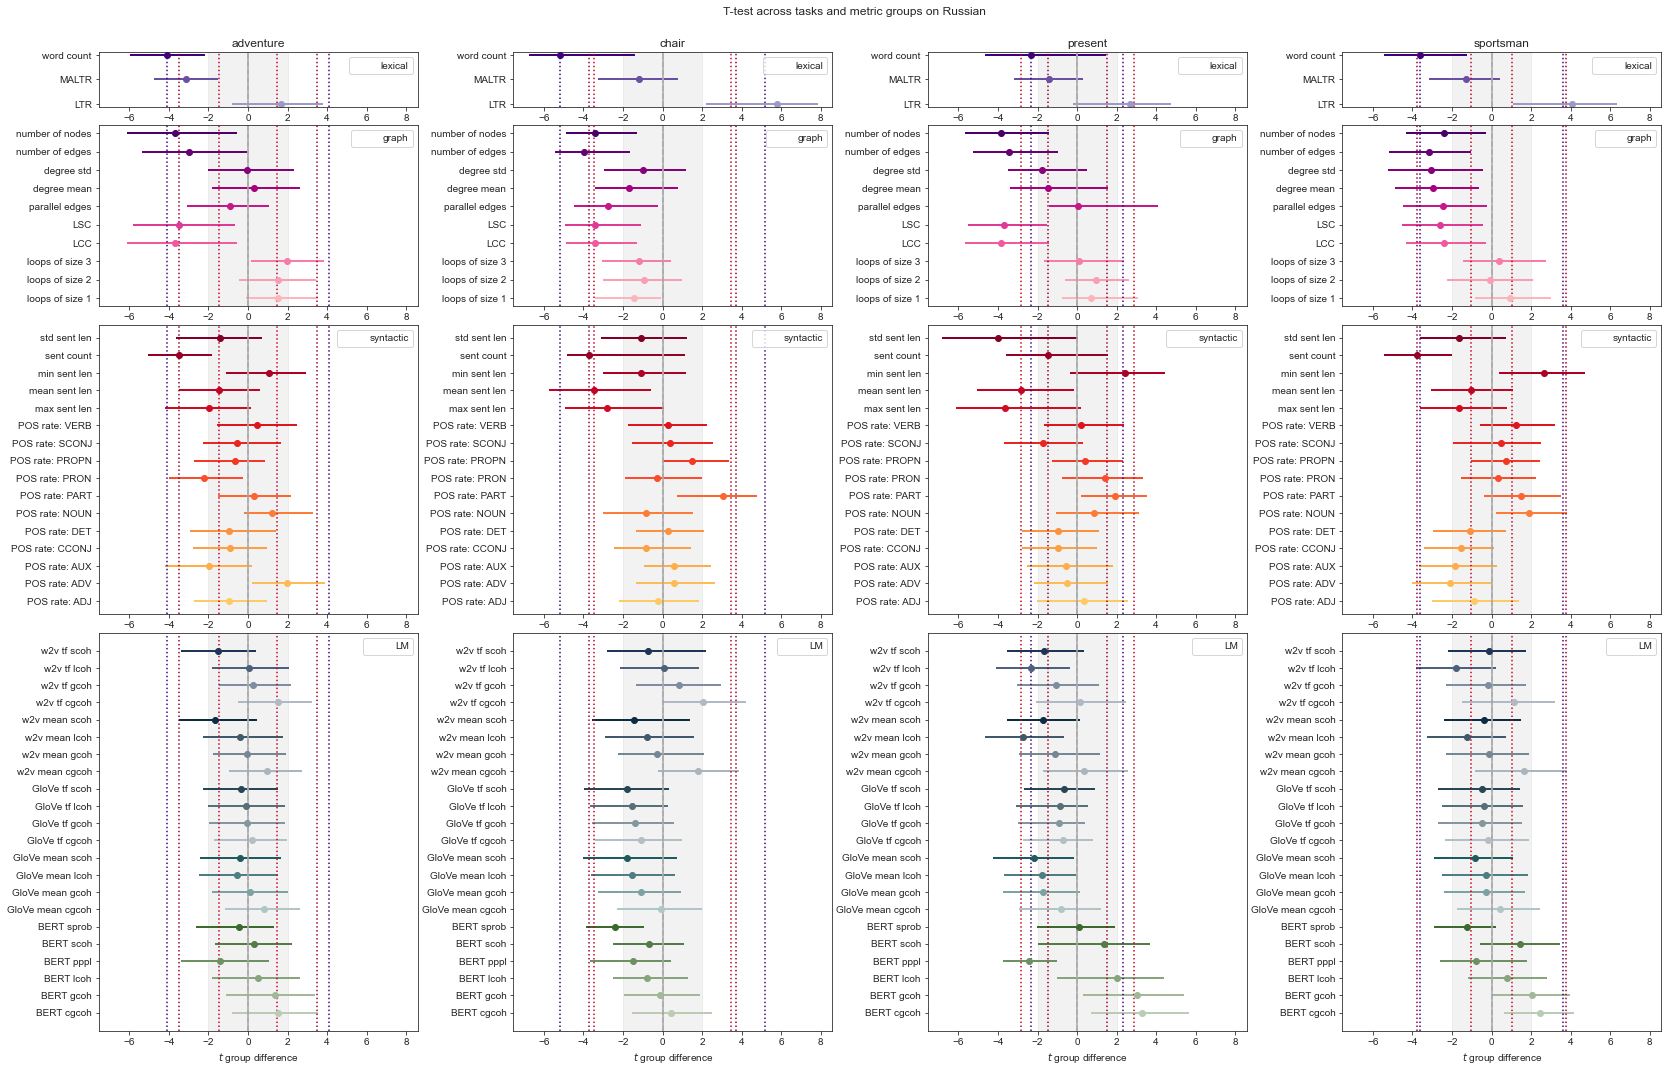

In [48]:
fig, axes = plt.subplots(4, 4, figsize=(28, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

lang_ = 'ru'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, task in enumerate(long_df[long_df['lang'] == lang_]["task"].unique()):
        ax = axes[i, j]
        data = get_data(long_df, lang_, task, metric_group, scale='group_diff', performance_metric='t')
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang_, task, scale='group_diff', performance_metric='t')
        add_grey(ax, r=2)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(task)
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

language_for_title = f"Russian" if lang_ == "ru" else "German"
fig.suptitle(f"T-test across tasks and metric groups on {language_for_title}", y=0.915);
plt.savefig(f'{PATH_FIG}{lang_}_t-test_all_tasks_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
plt.show()
plt.close()

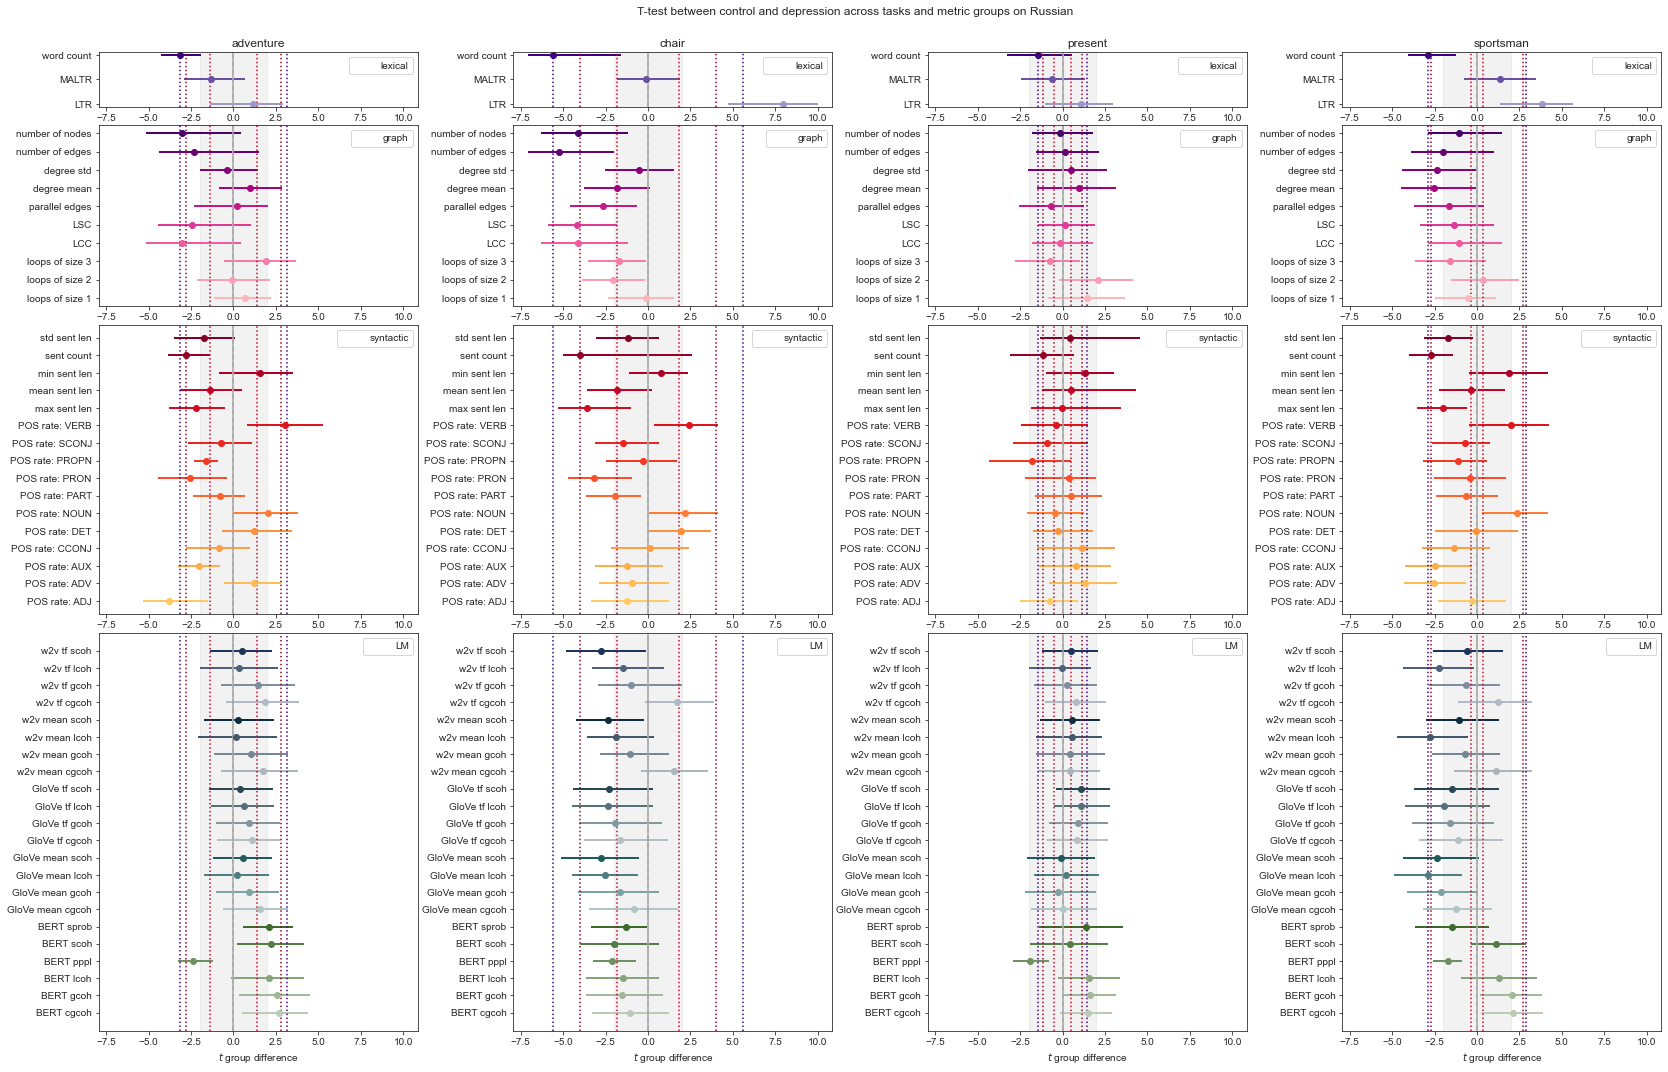

In [49]:
fig, axes = plt.subplots(4, 4, figsize=(28, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

lang_ = 'ru'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, task in enumerate(long_df[long_df['lang'] == lang_]["task"].unique()):
        ax = axes[i, j]
        data = get_data(long_df, lang_, task, metric_group, scale='group_diff_dep', performance_metric='t')
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang_, task, scale='group_diff_dep', performance_metric='t')
        add_grey(ax, r=2)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(task)
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

language_for_title = f"Russian" if lang_ == "ru" else "German"
fig.suptitle(f"T-test between control and depression across tasks and metric groups on {language_for_title}", y=0.915);
plt.savefig(f'{PATH_FIG}{lang_}_t-test_dep_all_tasks_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
plt.show()
plt.close()

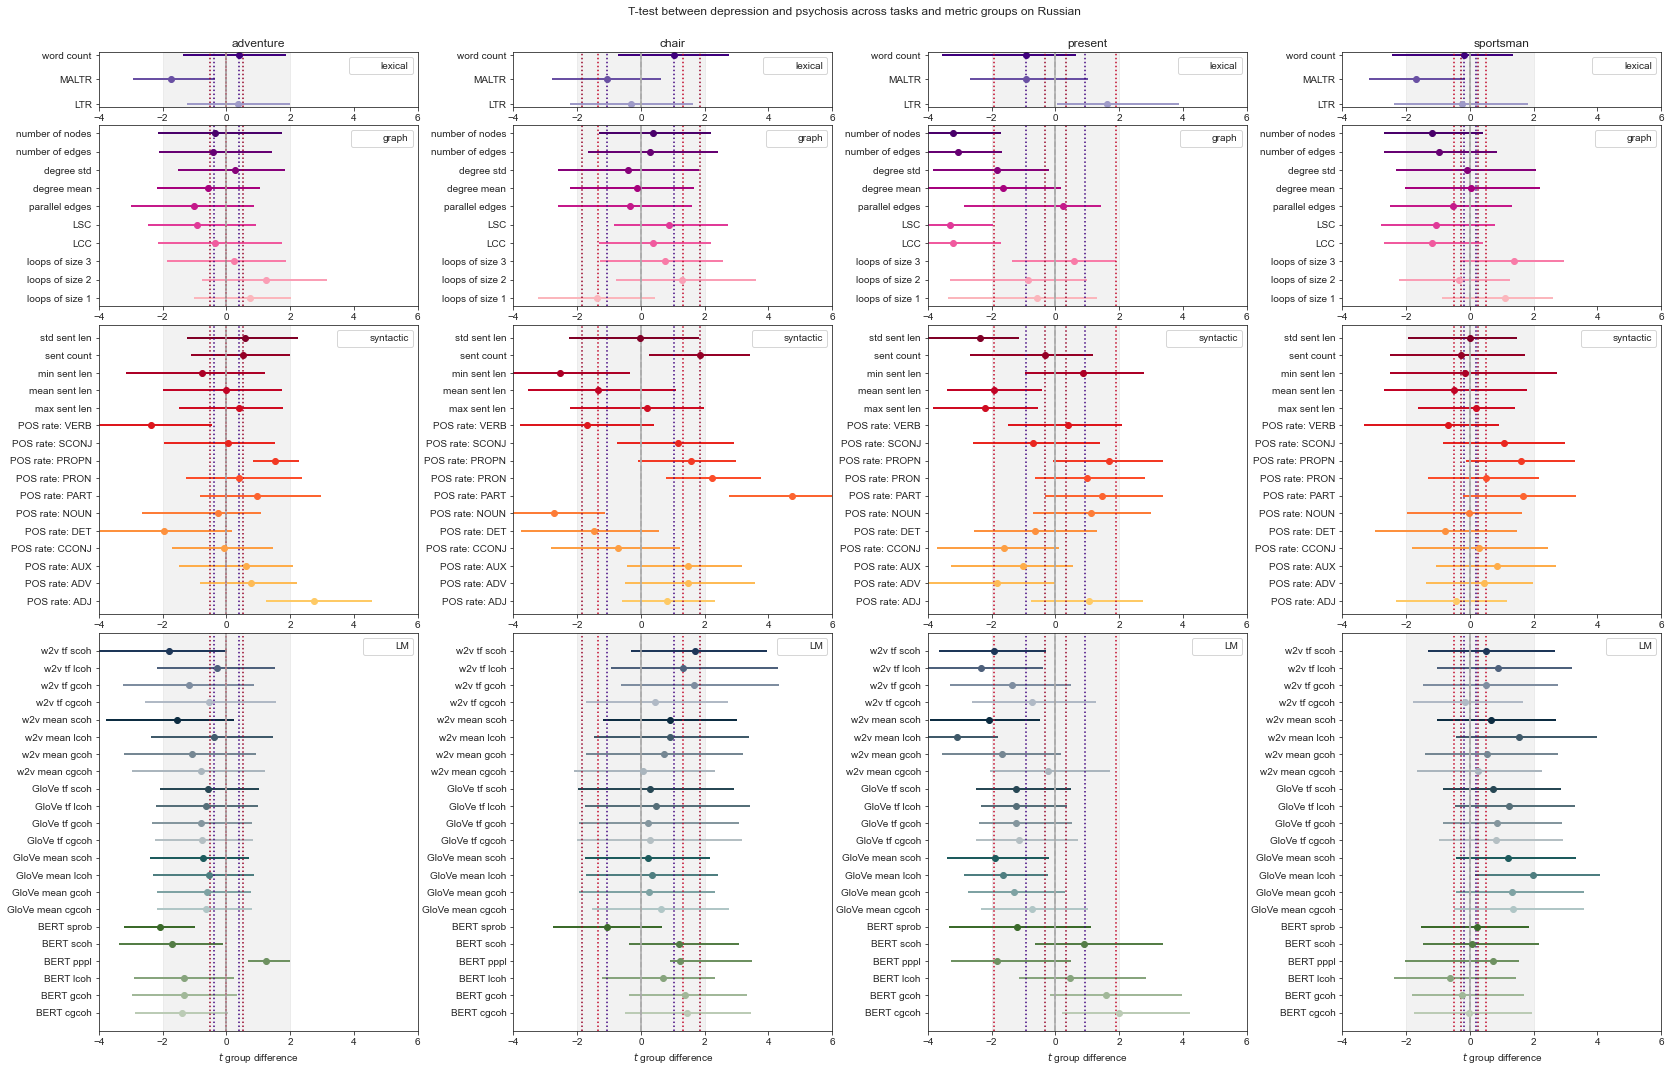

In [50]:
fig, axes = plt.subplots(4, 4, figsize=(28, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

lang_ = 'ru'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, task in enumerate(long_df[long_df['lang'] == lang_]["task"].unique()):
        ax = axes[i, j]
        data = get_data(long_df, lang_, task, metric_group, scale='group_diff_sz_dep', performance_metric='t')
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang_, task, scale='group_diff_sz_dep', performance_metric='t')

        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(task)
            if j == 0:
                ax.set_xlim(-4, 6)
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)
        add_grey(ax, r=2)

language_for_title = f"Russian" if lang_ == "ru" else "German"
fig.suptitle(f"T-test between depression and psychosis across tasks and metric groups on {language_for_title}", y=0.915);
plt.savefig(f'{PATH_FIG}{lang_}_t-test_sz_dep_all_tasks_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
plt.show()
plt.close()

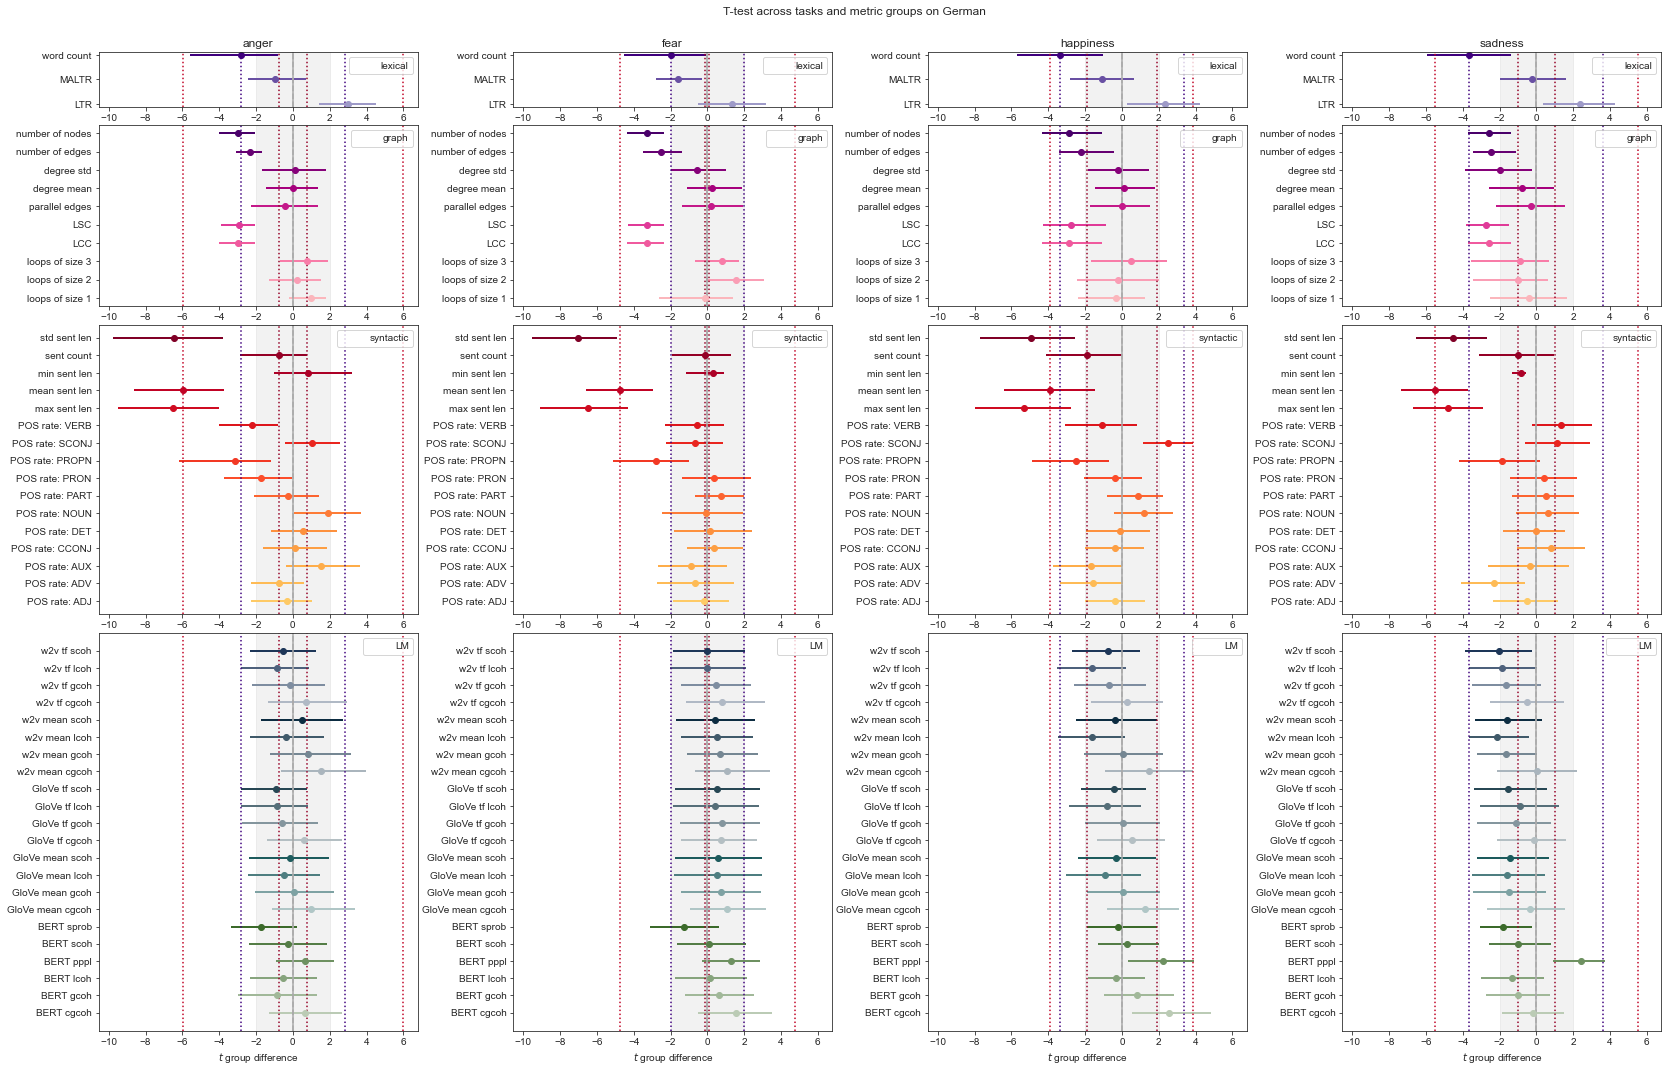

In [51]:
fig, axes = plt.subplots(4, 4, figsize=(28, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

lang_ = 'de'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, task in enumerate(long_df[long_df['lang'] == lang_]["task"].unique()):
        ax = axes[i, j]
        data = get_data(long_df, lang_, task, metric_group, scale='group_diff', performance_metric='t')
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang_, task, scale='group_diff', performance_metric='t')
        add_grey(ax, r=2)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(task)
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

language_for_title = f"Russian" if lang_ == "ru" else "German"
fig.suptitle(f"T-test across tasks and metric groups on {language_for_title}", y=0.915);
plt.savefig(f'{PATH_FIG}{lang_}_t-test_all_tasks_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
plt.show()
plt.close()

In [52]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        task = best_task[lang]
        data = get_data(long_df, lang, task, metric_group)
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang, task)
        add_grey(ax)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        if i == 3:
            ax.set_xlabel("$r$ symptom severity correlation (PANSS total score)")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle("Correlation with PANSS total on the best task across metric groups", y=0.915);
plt.savefig(f'{PATH_FIG}panss_total_best_task_all_metrics_across_languages.png', dpi=dpi, bbox_inches = 'tight')
# plt.show()
plt.close()

In [53]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        task = best_task[lang]
        data = get_data(long_df, lang, task, metric_group, scale='group_diff', performance_metric='t')
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, long_df, lang, task, scale='group_diff', performance_metric='t')
        add_grey(ax, r=2)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle("T-test on the best task across metric groups", y=0.915);
plt.savefig(f'{PATH_FIG}t-test_best_task_all_metrics_across_languages.png', dpi=dpi, bbox_inches = 'tight')
# plt.show()
plt.close()

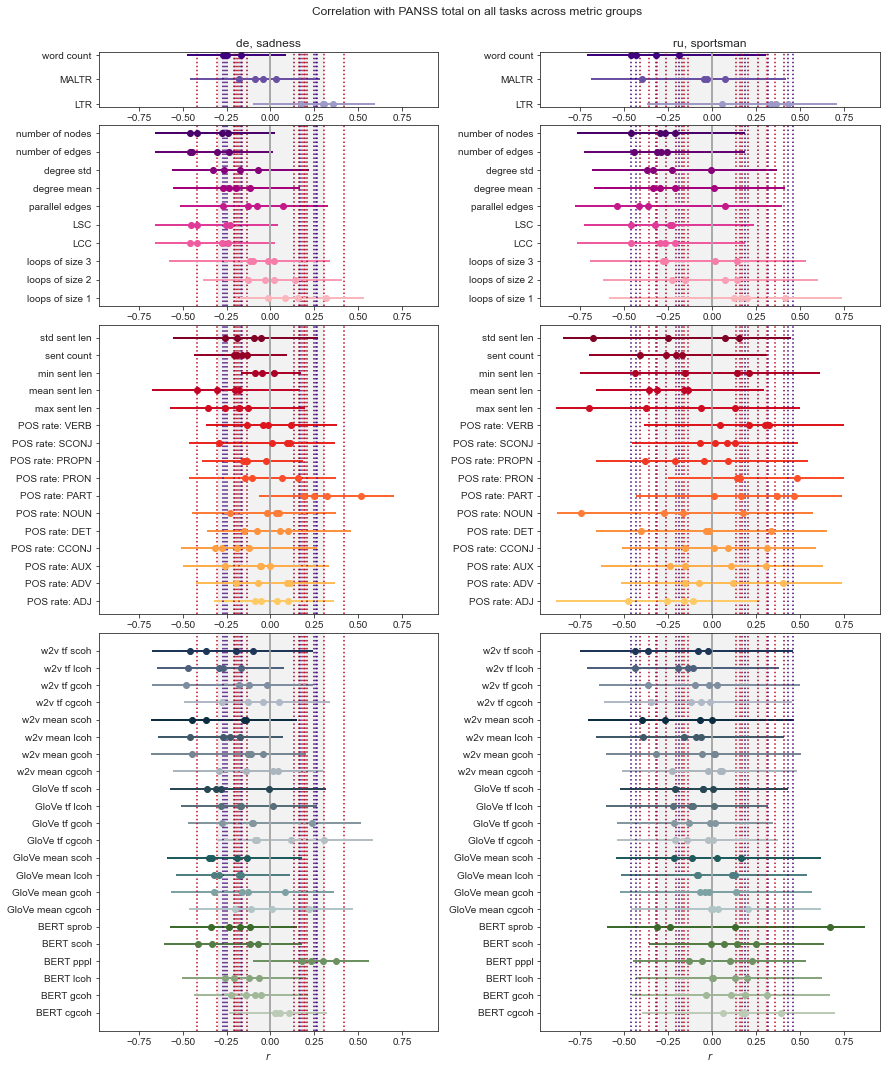

In [54]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        for task in long_df[long_df["lang"] == lang]["task"].unique():
            data = get_data(long_df, lang, task, metric_group)
            plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
            add_control_lines(ax, long_df, lang, task)
        add_grey(ax)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(f"{lang}, {task}")
        if i == 3:
            ax.set_xlabel("$r$")

fig.suptitle("Correlation with PANSS total on all tasks across metric groups", y=0.915);
plt.show()

plt.savefig(f'{PATH_FIG}panss_total_all_tasks_all_metrics_across_languages.png', dpi=dpi, bbox_inches = 'tight')
plt.close()

In [55]:
# long_df[(long_df['scale'] == 'ps_r_td.severity') & (long_df['subset'] == 'psychosis_only') & (long_df['task'] == 'adventure') & (long_df['metric_name'] == 'bert_sprob')]['median']

In [56]:
# long_df[(long_df['scale'] == 'ps_r_td.severity') & (long_df['subset'] == 'psychosis_only') & (long_df['task'] == 'adventure') & (long_df['metric_name'] == 'bert_sprob')]['median']

In [57]:
def mean_task_performance(df, metric_name, lang, unikey, key='median', abs_=True):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['unikey'] == unikey)][key]
    if abs_:
        data = data.abs()
    return np.nanmean(data)

In [58]:
def SE_low_high_task_performance(df, metric_name, lang, unikey, key='median', abs_=True):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['unikey'] == unikey)][key]
    if abs_:
        data = data.abs()
    se = np.std(data) / np.sqrt(len(data))
    return np.nanmean(data) - se,  np.nanmean(data) + se

In [59]:
def mean_CI_low_high_task_performance(df, metric_name, lang, unikey, key='median', abs_=True):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['unikey'] == unikey)]
    if abs_:
        data = data.abs()
    CI_low, CI_high = np.nanmean(data['CI_low']), np.nanmean(data['CI_high'])
    return CI_low, CI_high

In [60]:
mean_data = []
for lang in ["de", "ru"]:
    lang_data = long_df[long_df['lang'] == lang]
    for metric_name in long_df['metric_name'].unique():
        for unikey in lang_data['unikey'].unique():
            performance_metric = lang_data[lang_data['unikey'] == unikey]['performance_metric'].unique()[0]
            scale = lang_data[lang_data['unikey'] == unikey]['scale'].unique()[0]
            predictor_varset = lang_data[lang_data['unikey'] == unikey]['predictor_varset'].unique()[0]
            metric_group = lang_data[lang_data['metric_name'] == metric_name]["metric_group"].values[0]
            
            mean = mean_task_performance(lang_data, metric_name, lang, unikey, abs_=False)
            mean_SE_low, mean_SE_high = SE_low_high_task_performance(lang_data, metric_name, lang, unikey, abs_=False)
            mean_CI_low, mean_CI_high = mean_CI_low_high_task_performance(lang_data, metric_name, lang, unikey, abs_=False)
            line = (lang, 'mean', scale, performance_metric, predictor_varset,
                    unikey, metric_group, metric_name, mean,
                    mean_CI_low, mean_CI_high, mean_SE_low, mean_SE_high)
            for col in control_cols:
                mean_corr_control = mean_task_performance(lang_data, metric_name, lang, unikey, key=f'corr_{col}_median', abs_=False)
                mean_corr_control_abs = mean_task_performance(lang_data, metric_name, lang, unikey, key=f'corr_{col}_median', abs_=True)
                line += (mean_corr_control, mean_corr_control_abs)
            mean_data.append(line)

/var/folders/1l/2khv4cgj7xs0zrm9hnl_yrzh0000gn/T/ipykernel_1494/1360389259.py:5: RuntimeWarning: Mean of empty slice
  return np.nanmean(data)
/var/folders/1l/2khv4cgj7xs0zrm9hnl_yrzh0000gn/T/ipykernel_1494/1612108272.py:6: RuntimeWarning: Mean of empty slice
  return np.nanmean(data) - se,  np.nanmean(data) + se


In [61]:
task_mean_df = pd.DataFrame(mean_data, columns=['lang', 'task', 'scale', 'performance_metric',
                                                'predictor_varset', 'unikey',
                                                'metric_group', 'metric_name', 'median',
                                                'CI_low', 'CI_high', 'SE_low', 'SE_high',
                                                'corr_mean_sent_len_median', 'corr_mean_sent_len_median_abs',
                                                'corr_n_sents_median', 'corr_n_sents_median_abs',
                                                'corr_n_words_median', 'corr_n_words_median_abs'])

In [62]:
# task_mean_df[(task_mean_df['median'].isna()) & (task_mean_df['scale'] != 'multivariate')][['lang', 'unikey', 'metric_name']]

In [63]:
mean_data_dep = []
lang = "ru"
for metric_name in metric_to_color:
    for unikey in long_df_ru_dep_only['unikey'].unique():
        performance_metric = long_df_ru_dep_only[long_df_ru_dep_only['unikey'] == unikey]['performance_metric'].unique()[0]
        scale = long_df_ru_dep_only[long_df_ru_dep_only['unikey'] == unikey]['scale'].unique()[0]
        predictor_varset = long_df_ru_dep_only[long_df_ru_dep_only['unikey'] == unikey]['predictor_varset'].unique()[0]
        metric_group = long_df_ru_dep_only[long_df_ru_dep_only['metric_name'] == metric_name]["metric_group"].values[0]

        mean = mean_task_performance(long_df_ru_dep_only, metric_name, lang, unikey, abs_=False)
        mean_SE_low, mean_SE_high = SE_low_high_task_performance(long_df_ru_dep_only, metric_name, lang, unikey, abs_=False)
        mean_CI_low, mean_CI_high = mean_CI_low_high_task_performance(long_df_ru_dep_only, metric_name, lang, unikey, abs_=False)
        line = (lang, 'mean', scale, performance_metric, predictor_varset,
                unikey, metric_group, metric_name, mean,
                mean_CI_low, mean_CI_high, mean_SE_low, mean_SE_high)
        for col in control_cols:
            mean_corr_control = mean_task_performance(long_df_ru_dep_only, metric_name, lang, unikey, key=f'corr_{col}_median', abs_=False)
            mean_corr_control_abs = mean_task_performance(long_df_ru_dep_only, metric_name, lang, unikey, key=f'corr_{col}_median', abs_=True)
            line += (mean_corr_control, mean_corr_control_abs)
        mean_data_dep.append(line)

/var/folders/1l/2khv4cgj7xs0zrm9hnl_yrzh0000gn/T/ipykernel_1494/1360389259.py:5: RuntimeWarning: Mean of empty slice
  return np.nanmean(data)
/var/folders/1l/2khv4cgj7xs0zrm9hnl_yrzh0000gn/T/ipykernel_1494/1612108272.py:6: RuntimeWarning: Mean of empty slice
  return np.nanmean(data) - se,  np.nanmean(data) + se


In [64]:
task_mean_dep_df = pd.DataFrame(mean_data_dep, columns=['lang', 'task', 'scale', 'performance_metric',
                                                        'predictor_varset', 'unikey',
                                                        'metric_group', 'metric_name', 'median',
                                                        'CI_low', 'CI_high', 'SE_low', 'SE_high',
                                                        'corr_mean_sent_len_median', 'corr_mean_sent_len_median_abs',
                                                        'corr_n_sents_median', 'corr_n_sents_median_abs',
                                                        'corr_n_words_median', 'corr_n_words_median_abs'])

In [65]:
def max_abs_baseline(df, lang, task, unikey="panss_total_r_single", baselines=["n_sents", "n_words", "mean_sent_len"], value="median"):
    vals = df[(df["lang"] == lang) & (df["task"] == task) & (df["unikey"] == unikey) &
              df["metric_name"].isin(["n_sents", "n_words", "mean_sent_len"])][value]
    return np.nanmax(np.abs(vals))

In [66]:
def outperform_best_baseline(df, lang, task, unikey="panss_total_r_single", value="median"):
    best_baseline = max_abs_baseline(df, lang, task, unikey=unikey, value=value)
    df_slice = df[(df["lang"] == lang) & (df["task"] == task) & (df["unikey"] == unikey)
                 & (np.abs(df[value]) > best_baseline)]
    return df_slice["metric_name"]

In [67]:
max_abs_baseline(task_mean_df, "de", "mean", unikey="panss_total_r_single", value="median")

0.27640220523865894

In [68]:
max_abs_baseline(task_mean_df, "ru", "mean", unikey="panss_total_r_single", value="median")

0.3503717051439031

In [69]:
lang_ = 'ru'
metric_name_ = 'mean_sent_len'
r_mean_sent_len_ru = task_mean_df[(task_mean_df["lang"] == lang_) & (task_mean_df["unikey"] == "panss_total_r_single") & (task_mean_df["metric_name"] == metric_name_)]["median"].to_list()[0]
r_mean_sent_len_ru

-0.24161625420442662

In [70]:
lang_ = 'ru'
metric_name_ = 'n_sents'
r_n_sents_ru = task_mean_df[(task_mean_df["lang"] == lang_) & (task_mean_df["unikey"] == "panss_total_r_single") & (task_mean_df["metric_name"] == metric_name_)]["median"].to_list()[0]
r_n_sents_ru

-0.2619087070032042

In [71]:
lang_ = 'de'
task_mean_df[(task_mean_df["lang"] == lang_) & (task_mean_df["unikey"] == "panss_total_r_single") & (task_mean_df["metric_name"].isin(['LCC', 'LSC', 'number_of_nodes', 'number_of_edges']))]["median"].mean()

-0.34941263920412174

In [72]:
lang_ = 'ru'
task_mean_df[(task_mean_df["lang"] == lang_) & (task_mean_df["unikey"] == "panss_total_r_single") & (abs(task_mean_df["median"]) > abs(r_n_sents_ru))][["metric_name", "median"]]

,metric_name,median
1743,LCC,-0.308278
1771,LSC,-0.312988
1799,PE,-0.312154
1883,number_of_edges,-0.324171
1911,number_of_nodes,-0.308278
1939,LTR,0.296445
1995,n_words,-0.350372


In [73]:
(-0.308278+-0.312988+-0.324171+-0.308278 )/ 4

-0.31342875

In [74]:
best_de = outperform_best_baseline(task_mean_df, "de", "mean").to_list()
best_de

['w2v_avg_lcoh',
 'w2v_tf_lcoh',
 'w2v_tf_scoh',
 'LCC',
 'LSC',
 'number_of_edges',
 'number_of_nodes',
 'LTR',
 'PART']

In [75]:
best_ru = outperform_best_baseline(task_mean_df, "ru", "mean").to_list()
best_ru

[]

In [76]:
best_de = outperform_best_baseline(task_mean_df, "de", "mean", unikey="group_diff_t_single").to_list()
best_de

['max_sent_len', 'std_sent_len']

In [77]:
best_ru = outperform_best_baseline(task_mean_df, "ru", "mean", unikey="group_diff_t_single").to_list()
best_ru

[]

In [78]:
task_mean_df[(task_mean_df['unikey'] == 'panss_total_r2_diff_single') & (task_mean_df['metric_name'] == 'bert_pppl')]

,lang,task,scale,performance_metric,predictor_varset,unikey,metric_group,metric_name,median,CI_low,CI_high,SE_low,SE_high,corr_mean_sent_len_median,corr_mean_sent_len_median_abs,corr_n_sents_median,corr_n_sents_median_abs,corr_n_words_median,corr_n_words_median_abs
67,de,mean,panss_total,r2_diff,single,panss_total_r2_diff_single,LM,bert_pppl,0.035184,0.000175,0.212599,0.023800,0.046568,-0.376825,0.376825,-0.500817,0.500817,-0.546839,0.546839
1129,ru,mean,panss_total,r2_diff,single,panss_total_r2_diff_single,LM,bert_pppl,0.016568,0.000045,0.340193,0.014171,0.018966,-0.223195,0.223195,0.045995,0.233799,-0.059730,0.201947


In [79]:
task_mean_df[(task_mean_df['unikey'] == 'panss_total_r2_dc_bv_m') & (task_mean_df['metric_name'] == 'bert_pppl')]

,lang,task,scale,performance_metric,predictor_varset,unikey,metric_group,metric_name,median,CI_low,CI_high,SE_low,SE_high,corr_mean_sent_len_median,corr_mean_sent_len_median_abs,corr_n_sents_median,corr_n_sents_median_abs,corr_n_words_median,corr_n_words_median_abs
66,de,mean,panss_total,r2,dc_bv_m,panss_total_r2_dc_bv_m,LM,bert_pppl,0.326504,0.066763,0.650978,0.306836,0.346173,-0.376825,0.376825,-0.500817,0.500817,-0.546839,0.546839
1128,ru,mean,panss_total,r2,dc_bv_m,panss_total_r2_dc_bv_m,LM,bert_pppl,0.723491,0.225360,0.958889,0.692336,0.754646,-0.223195,0.223195,0.045995,0.233799,-0.059730,0.201947


In [80]:
task_mean_df[(task_mean_df['unikey'] == 'multivariate_r2_dc_bv') & (task_mean_df['metric_name'] == 'col_independent')]

,lang,task,scale,performance_metric,predictor_varset,unikey,metric_group,metric_name,median,CI_low,CI_high,SE_low,SE_high,corr_mean_sent_len_median,corr_mean_sent_len_median_abs,corr_n_sents_median,corr_n_sents_median_abs,corr_n_words_median,corr_n_words_median_abs
1035,de,mean,multivariate,r2,dc_bv,multivariate_r2_dc_bv,overview,col_independent,0.273728,0.039963,0.590348,0.247197,0.300260,NaN,NaN,NaN,NaN,NaN,NaN
2491,ru,mean,multivariate,r2,dc_bv,multivariate_r2_dc_bv,overview,col_independent,0.664150,0.155025,0.942323,0.630602,0.697699,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
# # median is the reason why panss_total_r2_diff_single != panss_total_r2_dc_bv_m - multivariate_r2_dc_bv
# x = [10, 20, 40, 50, 10]
# y = [10, 20, 45, 55, 15]
# z = [y_ - x_ for x_, y_ in zip(x, y)]
# print(np.median(x), np.median(y), np.median(z))
# print(np.mean(x), np.mean(y), np.mean(z))

In [82]:
cols_to_test_additionally = [('lexical','LTR'), ('graph', 'LCC'), ('graph', 'number_of_edges'), ('syntactic', 'PART'), ('LM', 'glove_tf_lcoh'), ('LM', 'bert_pppl')]

In [83]:
def plot_one_line_errorbar(ax, row, metric_name, predictor_varset, lang):
    if predictor_varset == "dc_bv":
        metric_name = best_verbosity_metric_map[lang]
    if predictor_varset in ("dc_bv", "dc_bv_m"):
        metric_name_to_plot = name_map[metric_name[1]]
        color = metric_to_color[metric_name[1]]
    elif predictor_varset in ("dc", "multi"):
        color = overview_model_to_color[predictor_varset]
        metric_name_to_plot = overview_model_to_name[predictor_varset]

    ax.errorbar(row['median'], metric_name_to_plot, 
                xerr=[[abs(row['median'] - row['CI_low'])], [abs(row['CI_high'] - row['median'])]], 
                color=color, capsize=0, elinewidth=2, marker="o")
    return metric_name_to_plot, color

de major covariates 0.08193979415961482
de mean sent len 0.3642212639003803
de LTR 0.38235141833237696
de LCC 0.45136301138853263
de number_of_edges 0.41061982494255533
de PART 0.38823106905450167
de glove_tf_lcoh 0.4308093377862009
de bert_pppl 0.391587515069425
de multivariate model 0.6029049536378568
ru major covariates 0.5900861427017707
ru word count 0.6988750943316784
ru LTR 0.7168554969541288
ru LCC 0.7234891823912811
ru number_of_edges 0.7166571865164555
ru PART 0.708654520851856
ru glove_tf_lcoh 0.7018144723237989
ru bert_pppl 0.7076638318411232
ru multivariate model 0.7537195857636375


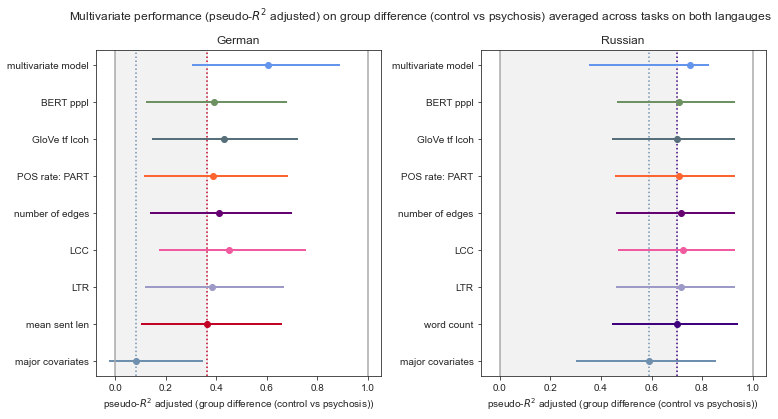

de major covariates 0.16204593670554324
de mean sent len 0.27372827771676966
de LTR 0.33132719435096314
de LCC 0.36005430065605265
de number_of_edges 0.37201563281624184
de PART 0.3452608413292154
de glove_tf_lcoh 0.3075939454257752
de bert_pppl 0.3265041754849782
de multivariate model 0.5091889039186113
ru major covariates 0.47980628306735384
ru word count 0.6641503563654024
ru LTR 0.7563637682270978
ru LCC 0.7569926099279173
ru number_of_edges 0.7557468390233332
ru PART 0.7894150950232698
ru glove_tf_lcoh 0.7524665557980639
ru bert_pppl 0.723490867455357
ru multivariate model 0.9634503302538239


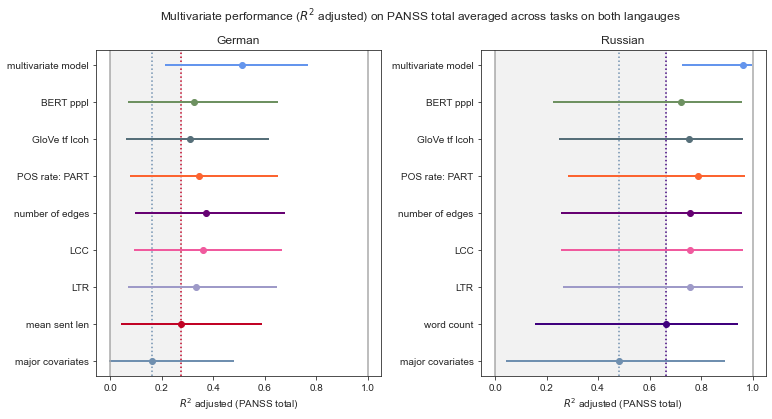

In [84]:
for pm in ['llh', 'r2']:
    metric_name_for_title = '$R^2$ adjusted' if pm == 'r2' else "pseudo-$R^2$ adjusted"
    scale_tit = 'PANSS total' if pm == 'r2' else "group difference (control vs psychosis)"
    scale_s = 'panss_total' if pm == 'r2' else 'group_diff'
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)
    plt.subplots_adjust(hspace=0.08, wspace=0.35)
    for i, lang_ in enumerate(["de", "ru"]):
        lang_df = task_mean_df[task_mean_df["lang"] == lang_]
        ax = axes[i]
        dc_bv_value = 0
        unikey_list = [f'multivariate_{pm}_dc', f'multivariate_{pm}_dc_bv', 
                       f'{scale_s}_{pm}_dc_bv_m', f'multivariate_{pm}_multi']

        for unikey in unikey_list:
            performance_metric = lang_df[lang_df["unikey"] == unikey].performance_metric.unique()[0]
            scale = lang_df[lang_df["unikey"] == unikey].scale.unique()[0]
            predictor_varset = lang_df[lang_df["unikey"] == unikey].predictor_varset.unique()[0]
            data = get_data(task_mean_df, lang_, 'mean', unikey=unikey)

            if unikey == f'{scale_s}_{pm}_dc_bv_m':
                for col in cols_to_test_additionally:
                    row = data[data['metric_name'] == col[1]].iloc[0]
                    plot_one_line_errorbar(ax, row, col, predictor_varset, lang_)
                    print(lang_, col[1], row['median'])
            else:
                row = data[data['metric_name'] == 'col_independent'].iloc[0]
                metric_name_to_plot, color = plot_one_line_errorbar(ax, row, 'col_independent', predictor_varset, lang_)
                value = row['median']
                print(lang_, metric_name_to_plot, row['median'])
                if unikey == f'multivariate_{pm}_dc_bv':
                    dc_bv_value = value
                    ax.axvline(dc_bv_value, color=color, linestyle=":")
                elif unikey == f'multivariate_{pm}_dc':
                    ax.axvline(value, color=color, linestyle=":") 
                    


        # Add labels and title
        ax.set_xlabel(f'{metric_name_for_title} ({scale_tit})')
        ax.axvline(0, color="darkgrey")
        ax.axvline(1, color="darkgrey")
        ax.set_title(f"Russian" if lang_ == "ru" else "German")
    #     add_grey(ax, r=dc_bv_value)
        ax.axvspan(0, dc_bv_value, color='grey', alpha=0.1)
        ax.xaxis.set_tick_params(labelbottom=True)

    fig.suptitle(f"Multivariate performance ({metric_name_for_title}) on {scale_tit} averaged across tasks on both langauges")
    plt.savefig(f'{PATH_FIG}{pm}_multivariate.png', dpi=dpi, bbox_inches = 'tight')
    plt.show()
#     plt.close()

In [85]:
plot_positive_unikeys = ['panss_total_r2_diff_single', 'group_diff_auc_single',
                        'group_diff_sz_dep_auc_single', 'group_diff_dep_auc_single',
                        'group_diff_llh_diff_single', 'group_diff_llh_diff_single', 
                        'group_diff_sz_dep_llh_diff_single']

In [86]:
# PLOT all single-pred values averaged across tasks
task = 'mean'
for unikey in task_mean_df["unikey"].unique():
    if any(x in unikey for x in ('saps', 'sans', 'dep', 'sz')):
        continue
    if not unikey.endswith("single"):
        continue
    fig, axes = plt.subplots(4, 2, figsize=(12, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
    plt.subplots_adjust(hspace=0.08, wspace=0.35)

    for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
        for j, lang_ in enumerate(["de", "ru"]):
            lang_df = task_mean_df[task_mean_df["lang"] == lang_]
            performance_metric = lang_df[lang_df["unikey"] == unikey].performance_metric.unique()[0]
            scale = lang_df[lang_df["unikey"] == unikey].scale.unique()[0]
            ax = axes[i, j]
            data = get_data(task_mean_df, lang_, task, metric_group, scale=scale, performance_metric=performance_metric)

            high_performers = outperform_best_baseline(task_mean_df, lang_, task, unikey=unikey).to_list()
            markers = {metric_name: 'd' if (metric_name in high_performers and 
                                            unikey not in plot_positive_unikeys) else '.'
                       for metric_name in data['metric_name']}

            plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None, markers=markers)
            if unikey not in plot_positive_unikeys:
                add_control_lines(ax, task_mean_df, lang_, task, scale=scale, performance_metric=performance_metric)
                add_grey(ax, r=max_abs_baseline(task_mean_df, lang_, task, unikey=unikey))
            if unikey in plot_positive_unikeys and 'diff' not in unikey:
                add_control_lines(ax, task_mean_df, lang_, task, scale=scale, performance_metric=performance_metric, use_neg=False)
                ax.axvspan(0, max_abs_baseline(task_mean_df, lang_, task, unikey=unikey), color='grey', alpha=0.1)

            ax.xaxis.set_tick_params(labelbottom=True)
            if i == 0:
                ax.set_title(f"Russian" if lang_ == "ru" else "German")
            if i == 3:
                ax.set_xlabel(f"{performance_metric} ({scale})")
            ax.plot([], [], ' ', label=metric_group)
            ax.legend(loc=1 if performance_metric != 'auc' else 2) # new

    fig.suptitle(f"Performance ({performance_metric}) on {scale} averaged across tasks", y=0.915)
    plt.savefig(f'{PATH_FIG}{unikey.replace(".", "_")}_average_task_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
#     plt.show()
    plt.close()

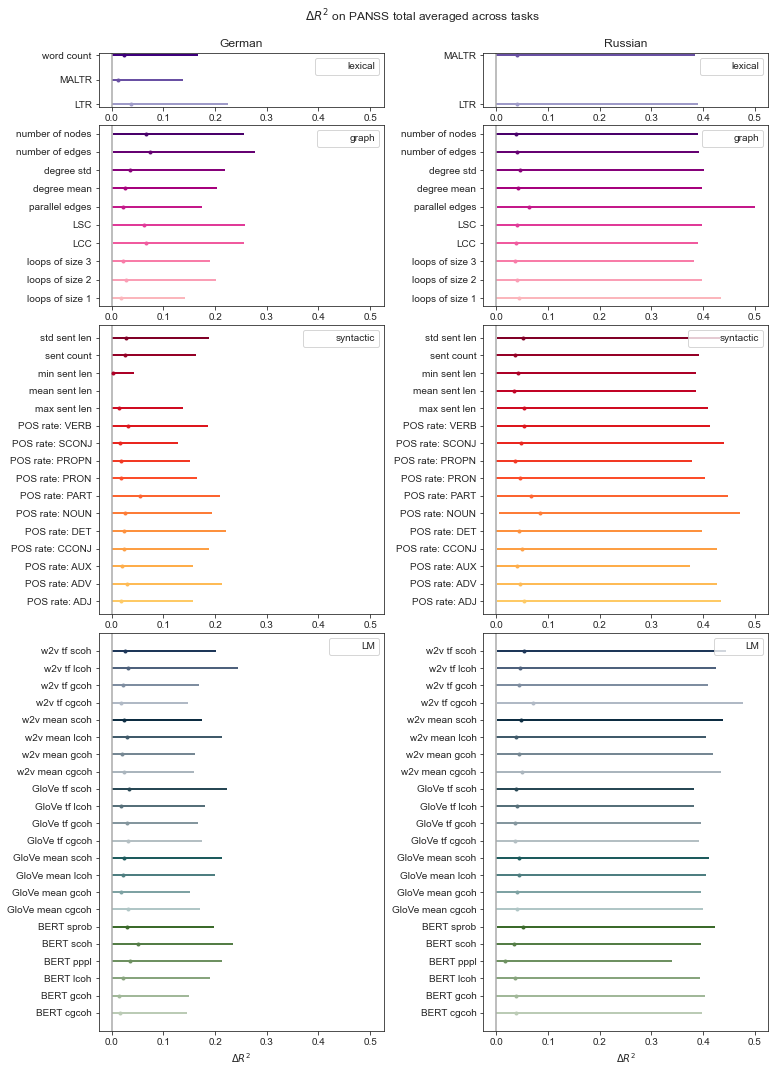

In [87]:
# PLOT all single-pred values averaged across tasks
task = 'mean'
unikey = 'panss_total_r2_diff_single'

fig, axes = plt.subplots(4, 2, figsize=(12, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.35)

for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, lang_ in enumerate(["de", "ru"]):
        lang_df = task_mean_df[task_mean_df["lang"] == lang_]
        performance_metric = lang_df[lang_df["unikey"] == unikey].performance_metric.unique()[0]
        scale = lang_df[lang_df["unikey"] == unikey].scale.unique()[0]
        ax = axes[i, j]
        data = get_data(task_mean_df, lang_, task, metric_group, scale=scale, performance_metric=performance_metric)

        high_performers = outperform_best_baseline(task_mean_df, lang_, task, unikey=unikey).to_list()
        markers = {metric_name: 'd' if (metric_name in high_performers and 
                                        unikey not in plot_positive_unikeys) else '.'
                   for metric_name in data['metric_name']}

        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None, markers=markers)
        if unikey not in plot_positive_unikeys:
            add_control_lines(ax, task_mean_df, lang_, task, scale=scale, performance_metric=performance_metric)
            add_grey(ax, r=max_abs_baseline(task_mean_df, lang_, task, unikey=unikey))
        if unikey in plot_positive_unikeys and 'diff' not in unikey:
            add_control_lines(ax, task_mean_df, lang_, task, scale=scale, performance_metric=performance_metric, use_neg=False)
            ax.axvspan(0, max_abs_baseline(task_mean_df, lang_, task, unikey=unikey), color='grey', alpha=0.1)

        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(f"Russian" if lang_ == "ru" else "German")
        if i == 3:
            ax.set_xlabel(f"$ΔR^2$")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1 if performance_metric != 'auc' else 2) # new

tit = f"$ΔR^2$ on PANSS total averaged across tasks"
fig.suptitle(tit, y=0.915)
plt.savefig(f'{PATH_FIG}{unikey.replace(".", "_")}_average_task_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
plt.show()
# plt.close()

In [88]:
# PLOT all single-pred values across tasks
for lang_ in ["ru", "de"]:
    lang_df = long_df[long_df["lang"] == lang_]
    for unikey in lang_df["unikey"].unique():
        if not unikey.endswith("single"):
            continue
        fig, axes = plt.subplots(4, 4, figsize=(24, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
        plt.subplots_adjust(hspace=0.08, wspace=0.35)

        for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
            for j, task in enumerate(lang_df["task"].unique()):
                performance_metric = lang_df[lang_df["unikey"] == unikey].performance_metric.unique()[0]
                scale = lang_df[lang_df["unikey"] == unikey].scale.unique()[0]
                ax = axes[i, j]
                data = get_data(long_df, lang_, task, metric_group, scale=scale, performance_metric=performance_metric)
                
                high_performers = outperform_best_baseline(long_df, lang_, task, unikey=unikey).to_list()
                markers = {metric_name: 'd' if (metric_name in high_performers and 
                                                unikey not in plot_positive_unikeys) else '.'
                           for metric_name in data['metric_name']}

                plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None, markers=markers)
                if unikey not in plot_positive_unikeys:
                    add_control_lines(ax, long_df, lang_, task, scale=scale, performance_metric=performance_metric)
                    add_grey(ax, r=max_abs_baseline(long_df, lang_, task, unikey=unikey))
                
                ax.xaxis.set_tick_params(labelbottom=True)
                if i == 0:
                    ax.set_title(task)
                if i == 3:
                    ax.set_xlabel(f"{performance_metric} ({scale})")
                ax.plot([], [], ' ', label=metric_group)
                ax.legend(loc=1)

        language_for_title = f"Russian" if lang_ == "ru" else "German"
        fig.suptitle(f"Performance {(performance_metric)} on {scale} across tasks and metric groups on {language_for_title}", y=0.915)
        plt.savefig(f'{PATH_FIG}{lang_}_{unikey.replace(".", "_")}_all_tasks_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
#         plt.show()
        plt.close()

In [89]:
# fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
# plt.subplots_adjust(hspace=0.08, wspace=0.31)
# lang_ = 'ru'
# for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
#     for j, group_df in enumerate([task_mean_df, task_mean_dep_df]):
#         ax = axes[i, j]
#         data = get_data(group_df, lang_, 'mean', metric_group, scale='panss_neg')
#         high_performers = outperform_best_baseline(group_df, lang_, 'mean', scale='panss_neg').to_list()
#         markers = {metric_name: 'd' if metric_name in high_performers else '.'
#                    for metric_name in data['metric_name']}
#         # https://matplotlib.org/stable/api/markers_api.html#module-matplotlib.markers
#         plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None, markers=markers)
#         add_control_lines(ax, group_df, lang_, 'mean', scale='panss_neg')
#         add_grey(ax, r=max_abs_baseline(group_df, lang_, 'mean', scale='panss_neg'))
#         ax.xaxis.set_tick_params(labelbottom=True)
#         if i == 0:
#             ax.set_title(f"psychosis" if j == 0 else "depression")
#         if i == 3:
#             ax.set_xlabel("$r$ negative symptom severity correlation (PANSS negative score)")
#         ax.plot([], [], ' ', label=metric_group)
#         ax.legend(loc=1)
#
# fig.suptitle("Correlation with PANSS negative averaged across tasks for all metric groups on psychosis vs depression groups", y=0.915);
# # plt.savefig(f'{PATH_FIG}panss_total_mean_task_all_metrics_across_languages.png', dpi=dpi, bbox_inches = 'tight')
# # plt.show()

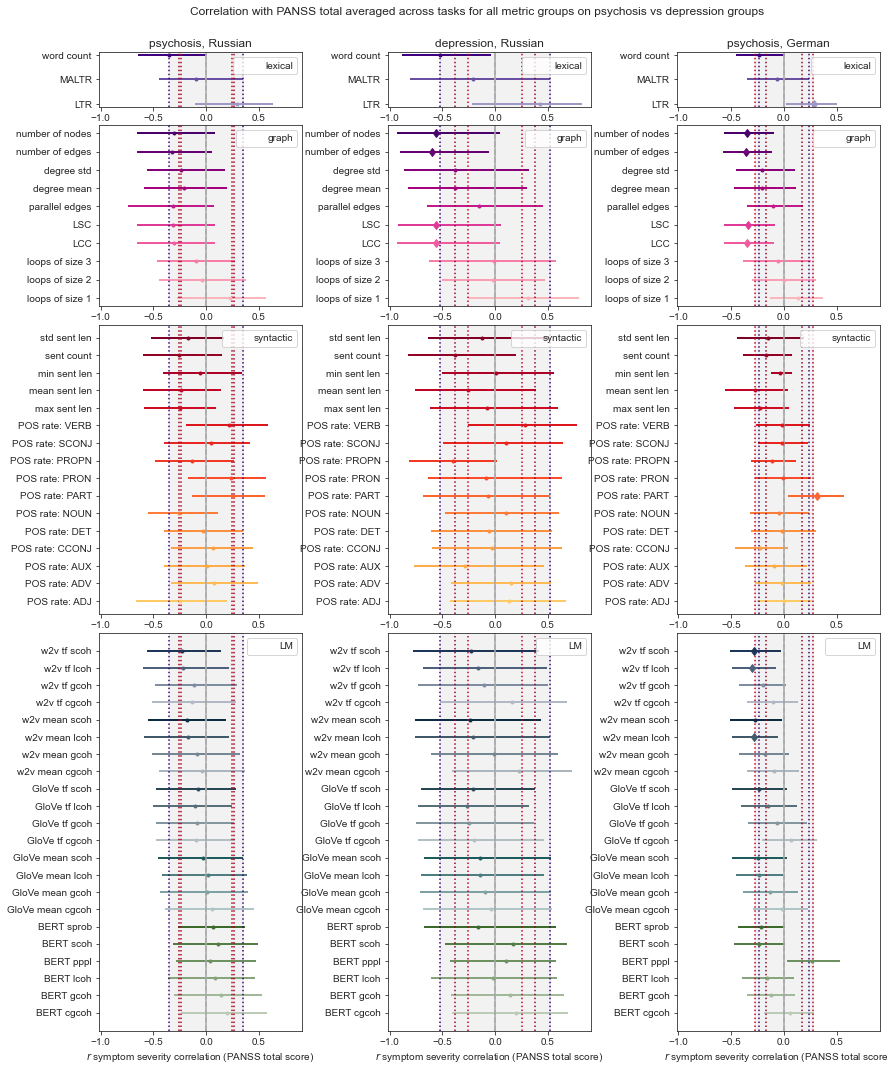

In [90]:
fig, axes = plt.subplots(4, 3, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.42)
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, group_df in enumerate([task_mean_df, task_mean_dep_df, task_mean_df[task_mean_df['lang'] == 'de']]):
        ax = axes[i, j]
        lang_ = 'ru' if j <= 1 else 'de'
        data = get_data(group_df, lang_, 'mean', metric_group)
        high_performers = outperform_best_baseline(group_df, lang_, 'mean').to_list()
        markers = {metric_name: 'd' if metric_name in high_performers else '.'
                   for metric_name in data['metric_name']}
        # https://matplotlib.org/stable/api/markers_api.html#module-matplotlib.markers
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None, markers=markers)
        add_control_lines(ax, group_df, lang_, 'mean')
        add_grey(ax, r=max_abs_baseline(group_df, lang_, 'mean'))
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(['psychosis, Russian', 'depression, Russian', 'psychosis, German'][j])
        if i == 3:
            ax.set_xlabel("$r$ symptom severity correlation (PANSS total score)")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle("Correlation with PANSS total averaged across tasks for all metric groups on psychosis vs depression groups", y=0.915);
plt.savefig(f'{PATH_FIG}panss_total_mean_task_all_metrics_across_languages_dep_vs_sz.png', dpi=dpi, bbox_inches = 'tight')
plt.show()

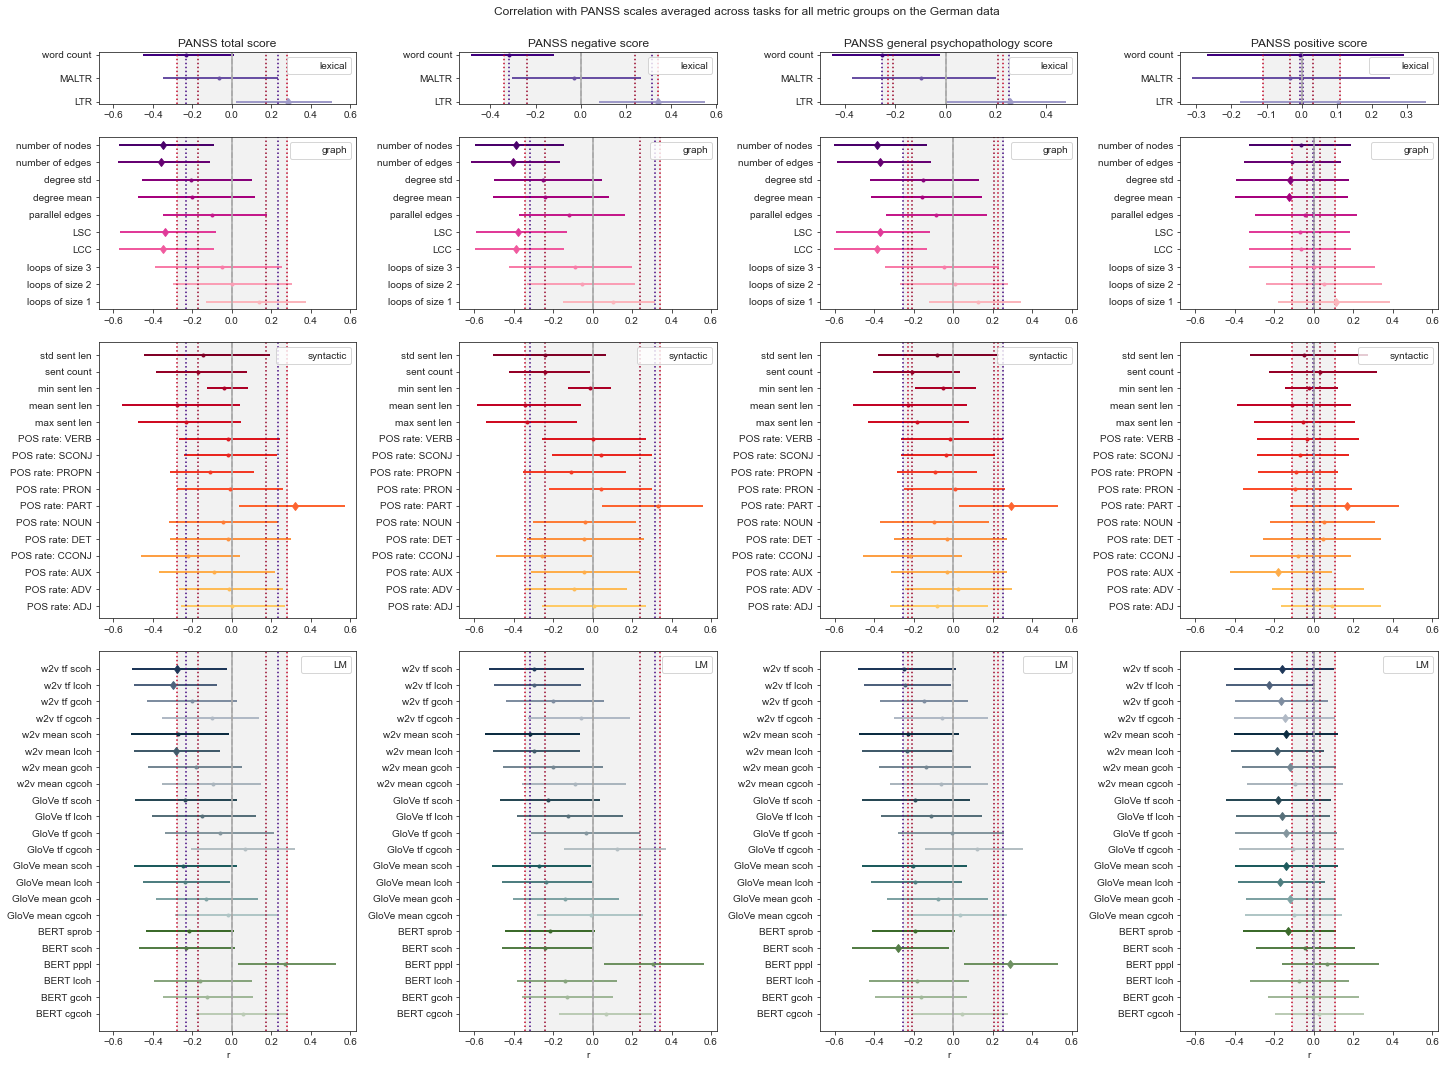

In [91]:
fig, axes = plt.subplots(4, 4, figsize=(24, 18), gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.15, wspace=0.4)

lang  = 'de'
panss_to_title = {'panss_total': "PANSS total score",
 'panss_neg': "PANSS negative score",
 'panss_o': "PANSS general psychopathology score",
 'panss_pos': "PANSS positive score"
}
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, scale_tit in enumerate(panss_to_title.items()):
        scale, tit = scale_tit
        performance_metric = "r"
        ax = axes[i, j]
        data = get_data(task_mean_df, lang, 'mean', metric_group, scale=scale, performance_metric=performance_metric)
        unikey = data['unikey'].values[0]
        high_performers = outperform_best_baseline(task_mean_df, lang, 'mean', unikey=unikey).to_list()
        markers = {metric_name: 'd' if metric_name in high_performers else '.'
                   for metric_name in data['metric_name']}
        # https://matplotlib.org/stable/api/markers_api.html#module-matplotlib.markers
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None, markers=markers)
        add_control_lines(ax, task_mean_df, lang, 'mean', scale=scale, performance_metric=performance_metric)
        add_grey(ax, r=max_abs_baseline(task_mean_df, lang, 'mean', unikey=unikey))
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(tit)
        if i == 3:
            ax.set_xlabel(f"{performance_metric}")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)
        if j < 4 and i > 0:
            ax.sharex(axes[0, 0])
        elif j == 4 and i > 0:
            ax.sharex(axes[0, 4])


fig.suptitle("Correlation with PANSS scales averaged across tasks for all metric groups on the German data", y=0.915)
plt.savefig(f'{PATH_FIG}{lang}_all_scales_mean_task_panss_subscales.png', dpi=dpi, bbox_inches = 'tight')
plt.show()

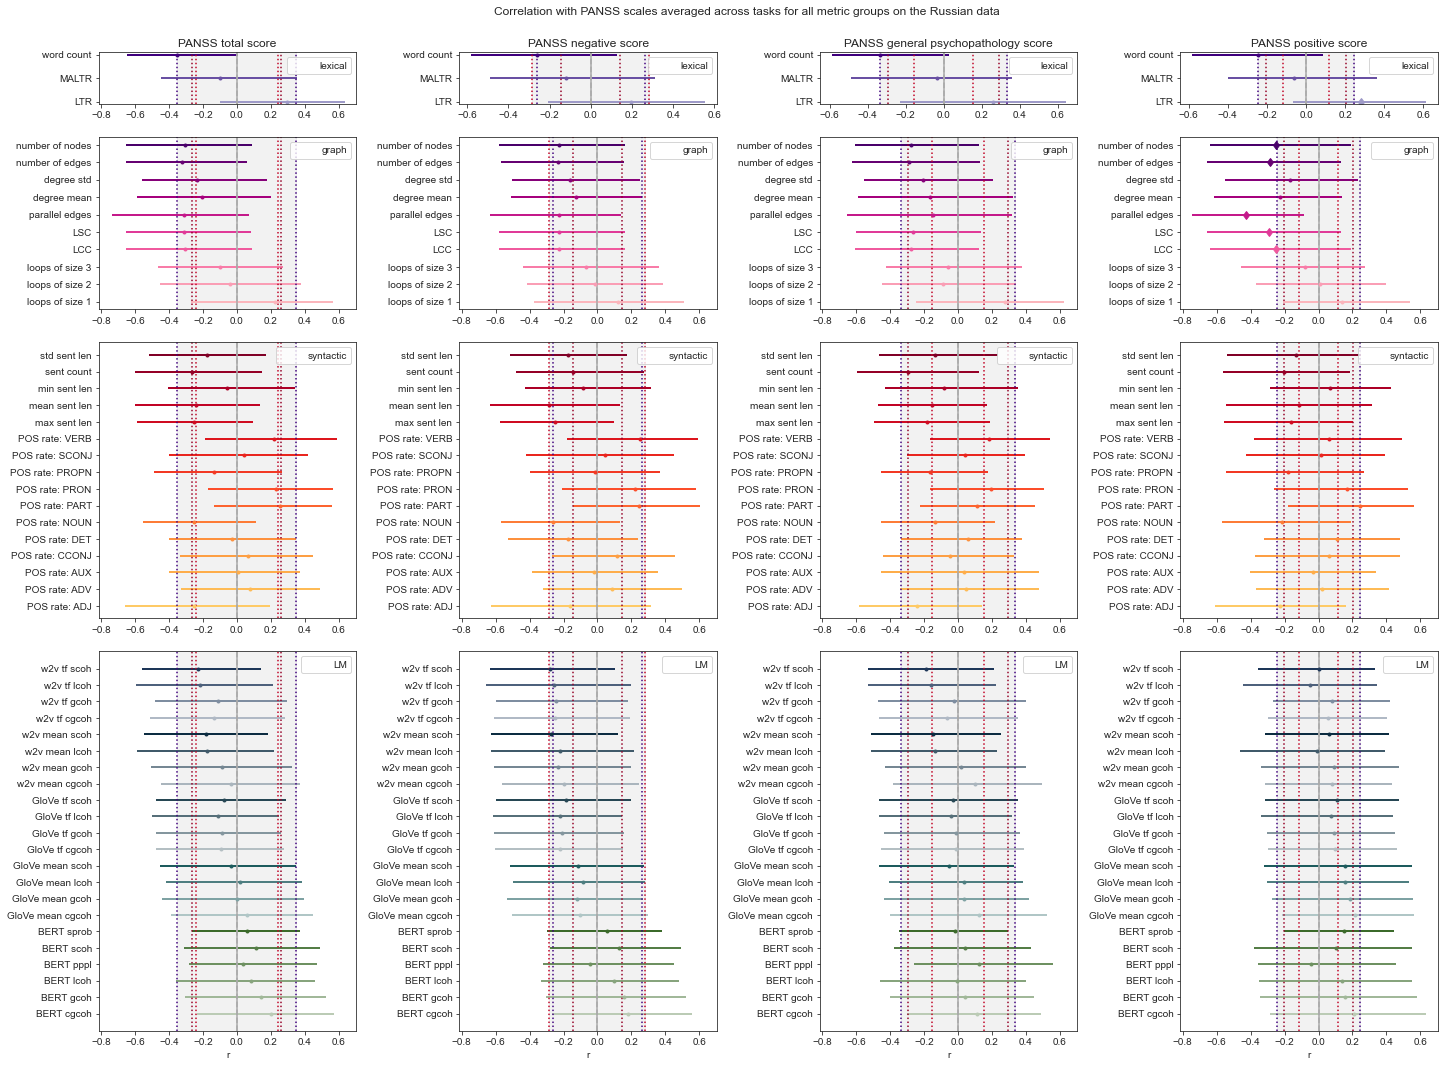

In [92]:
fig, axes = plt.subplots(4, 4, figsize=(24, 18), gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.15, wspace=0.4)

lang  = 'ru'
panss_to_title = {'panss_total': "PANSS total score",
 'panss_neg': "PANSS negative score",
 'panss_o': "PANSS general psychopathology score",
 'panss_pos': "PANSS positive score"
}
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, scale_tit in enumerate(panss_to_title.items()):
        scale, tit = scale_tit
        performance_metric = "r"
        ax = axes[i, j]
        data = get_data(task_mean_df, lang, 'mean', metric_group, scale=scale, performance_metric=performance_metric)
        unikey = data['unikey'].values[0]
        high_performers = outperform_best_baseline(task_mean_df, lang, 'mean', unikey=unikey).to_list()
        markers = {metric_name: 'd' if metric_name in high_performers else '.'
                   for metric_name in data['metric_name']}
        # https://matplotlib.org/stable/api/markers_api.html#module-matplotlib.markers
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None, markers=markers)
        add_control_lines(ax, task_mean_df, lang, 'mean', scale=scale, performance_metric=performance_metric)
        add_grey(ax, r=max_abs_baseline(task_mean_df, lang, 'mean', unikey=unikey))
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(tit)
        if i == 3:
            ax.set_xlabel(f"{performance_metric}")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)
        if j < 4 and i > 0:
            ax.sharex(axes[0, 0])
        elif j == 4 and i > 0:
            ax.sharex(axes[0, 4])


fig.suptitle("Correlation with PANSS scales averaged across tasks for all metric groups on the Russian data", y=0.915)
plt.savefig(f'{PATH_FIG}{lang}_all_scales_mean_task_panss_subscales.png', dpi=dpi, bbox_inches = 'tight')
plt.show()

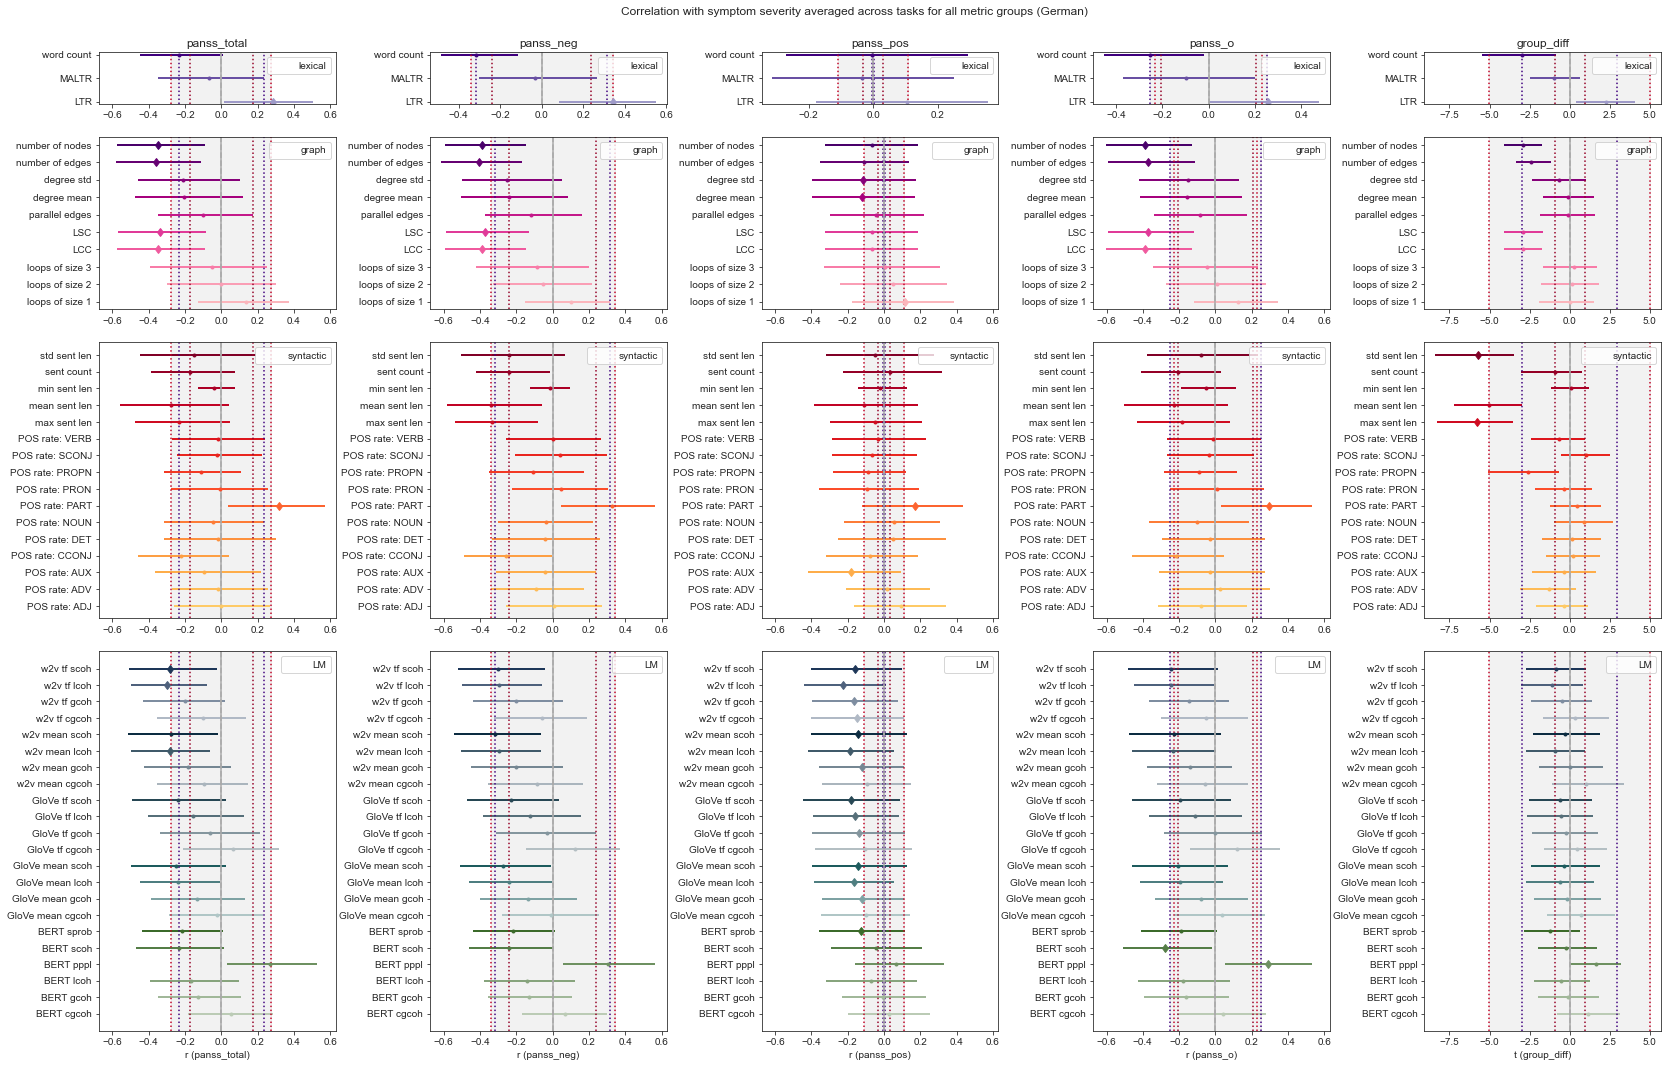

In [93]:
fig, axes = plt.subplots(4, 5, figsize=(28, 18), gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.15, wspace=0.4)

lang  = 'de'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, scale in enumerate(['panss_total', 'panss_neg', 'panss_pos', 'panss_o', 'group_diff']):
        performance_metric = "r" if scale != 'group_diff' else "t"
        ax = axes[i, j]
        data = get_data(task_mean_df, lang, 'mean', metric_group, scale=scale, performance_metric=performance_metric)
        unikey = data['unikey'].values[0]
        high_performers = outperform_best_baseline(task_mean_df, lang, 'mean', unikey=unikey).to_list()
        markers = {metric_name: 'd' if metric_name in high_performers else '.'
                   for metric_name in data['metric_name']}
        # https://matplotlib.org/stable/api/markers_api.html#module-matplotlib.markers
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None, markers=markers)
        add_control_lines(ax, task_mean_df, lang, 'mean', scale=scale, performance_metric=performance_metric)
        add_grey(ax, r=max_abs_baseline(task_mean_df, lang, 'mean', unikey=unikey))
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(scale)
        if i == 3:
            ax.set_xlabel(f"{performance_metric} ({scale})")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)
        if j < 4 and i > 0:
            ax.sharex(axes[0, 0])
        elif j == 4 and i > 0:
            ax.sharex(axes[0, 4])


fig.suptitle("Correlation with symptom severity averaged across tasks for all metric groups (German)", y=0.915)
plt.savefig(f'{PATH_FIG}{lang_}_all_scales_mean_task_all_metrics.png', dpi=dpi, bbox_inches = 'tight')
plt.show()

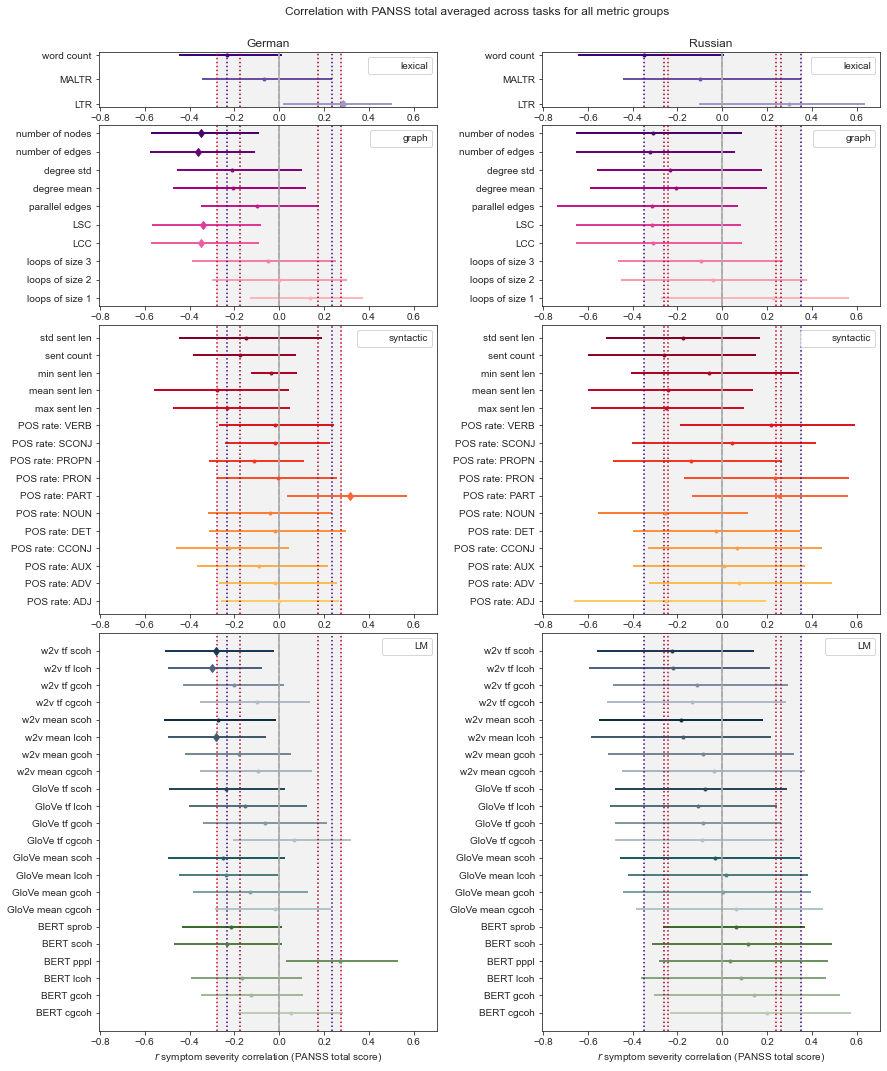

In [94]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.31)

for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        data = get_data(task_mean_df, lang, 'mean', metric_group)
        unikey = data['unikey'].values[0]
        high_performers = outperform_best_baseline(task_mean_df, lang, 'mean', unikey=unikey).to_list()
        markers = {metric_name: 'd' if metric_name in high_performers else '.' 
                   for metric_name in data['metric_name']}
        # https://matplotlib.org/stable/api/markers_api.html#module-matplotlib.markers
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None, markers=markers)
        add_control_lines(ax, task_mean_df, lang, 'mean')
        add_grey(ax, r=max_abs_baseline(task_mean_df, lang, 'mean', unikey=unikey))
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        if i == 3:
            ax.set_xlabel("$r$ symptom severity correlation (PANSS total score)")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle("Correlation with PANSS total averaged across tasks for all metric groups", y=0.915);
plt.savefig(f'{PATH_FIG}panss_total_mean_task_all_metrics_across_languages.png', dpi=dpi, bbox_inches = 'tight')
plt.show()

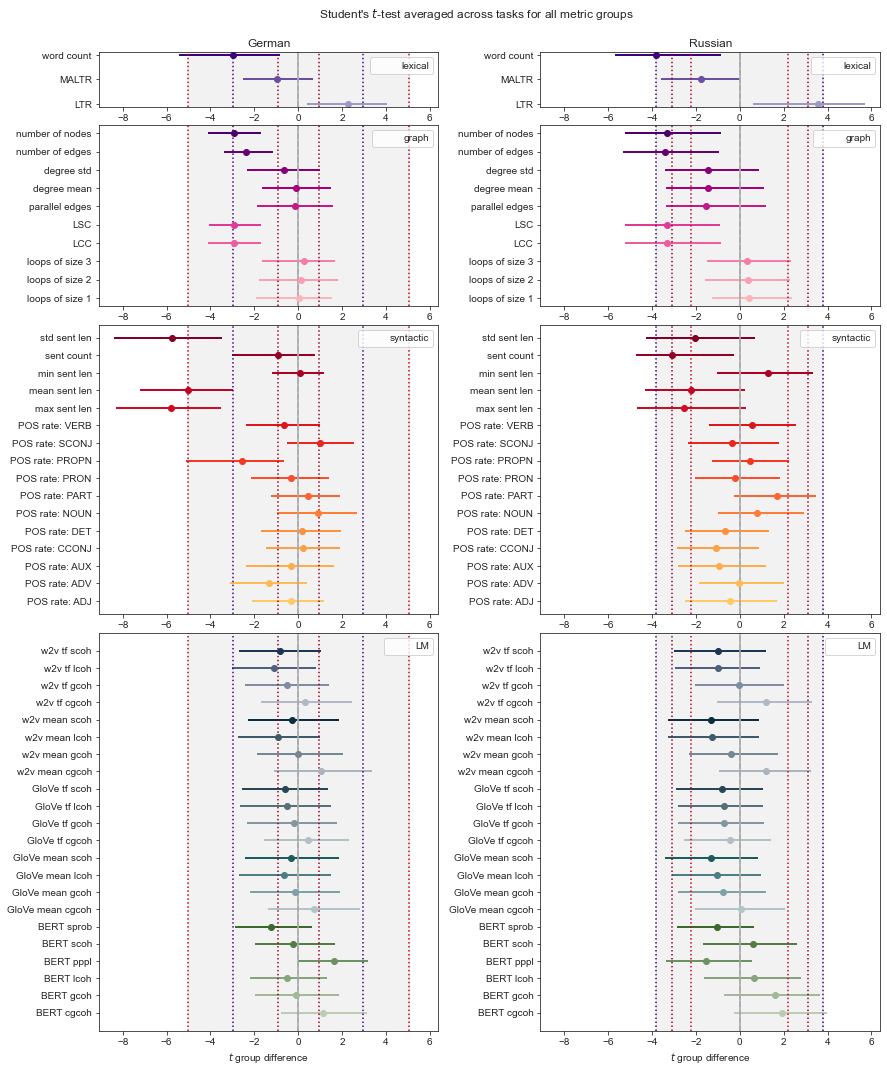

In [95]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        data = get_data(task_mean_df, lang, 'mean', metric_group, scale='group_diff', performance_metric='t')
        unikey = data['unikey'].values[0]
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, task_mean_df, lang, 'mean', scale='group_diff', performance_metric='t')
        add_grey(ax, r=max_abs_baseline(task_mean_df, lang, 'mean', unikey=unikey))
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle("Student's $t$-test averaged across tasks for all metric groups", y=0.915);
plt.savefig(f'{PATH_FIG}t-test_mean_task_all_metrics_across_languages.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [96]:
gd_name_map = {'group_diff': 'control vs psychosis', 'group_diff_sz_dep': 'depression vs psychosis', 'group_diff_dep': 'control vs depression'}

In [97]:
tru = get_data(task_mean_df, 'ru', 'mean', scale='group_diff', performance_metric='t')
tru = tru[tru['metric_group'] != "overview"]
tdru = get_data(task_mean_df, 'ru', 'mean', scale='group_diff_dep', performance_metric='t')
tdru = tdru[tdru['metric_group'] != "overview"]

In [98]:
stats.pearsonr(tru["median"], tdru["median"])

PearsonRResult(statistic=0.8490844974383095, pvalue=3.4822271045002254e-15)

In [99]:
tdru['abs_median'] = tdru['median'].abs().values
tdru[['abs_median', 'metric_name']].sort_values('abs_median', ascending=False).head(10)

,abs_median,metric_name
1945,3.502777,LTR
2001,3.261198,n_words
2421,2.677707,n_sents
1889,2.360738,number_of_edges
1749,2.101474,LCC
1917,2.101474,number_of_nodes
1133,2.033861,bert_pppl
1777,1.967537,LSC
2337,1.955984,max_sent_len
2309,1.777415,VERB


In [100]:
tru['abs_median'] = tru['median'].abs().values
tru[['abs_median', 'metric_name']].sort_values('abs_median', ascending=False).head(10)

,abs_median,metric_name
1999,3.811550,n_words
1943,3.558671,LTR
1887,3.392461,number_of_edges
1747,3.335678,LCC
1915,3.335678,number_of_nodes
1775,3.298280,LSC
2419,3.111055,n_sents
2335,2.526935,max_sent_len
2363,2.201436,mean_sent_len
2447,2.041583,std_sent_len


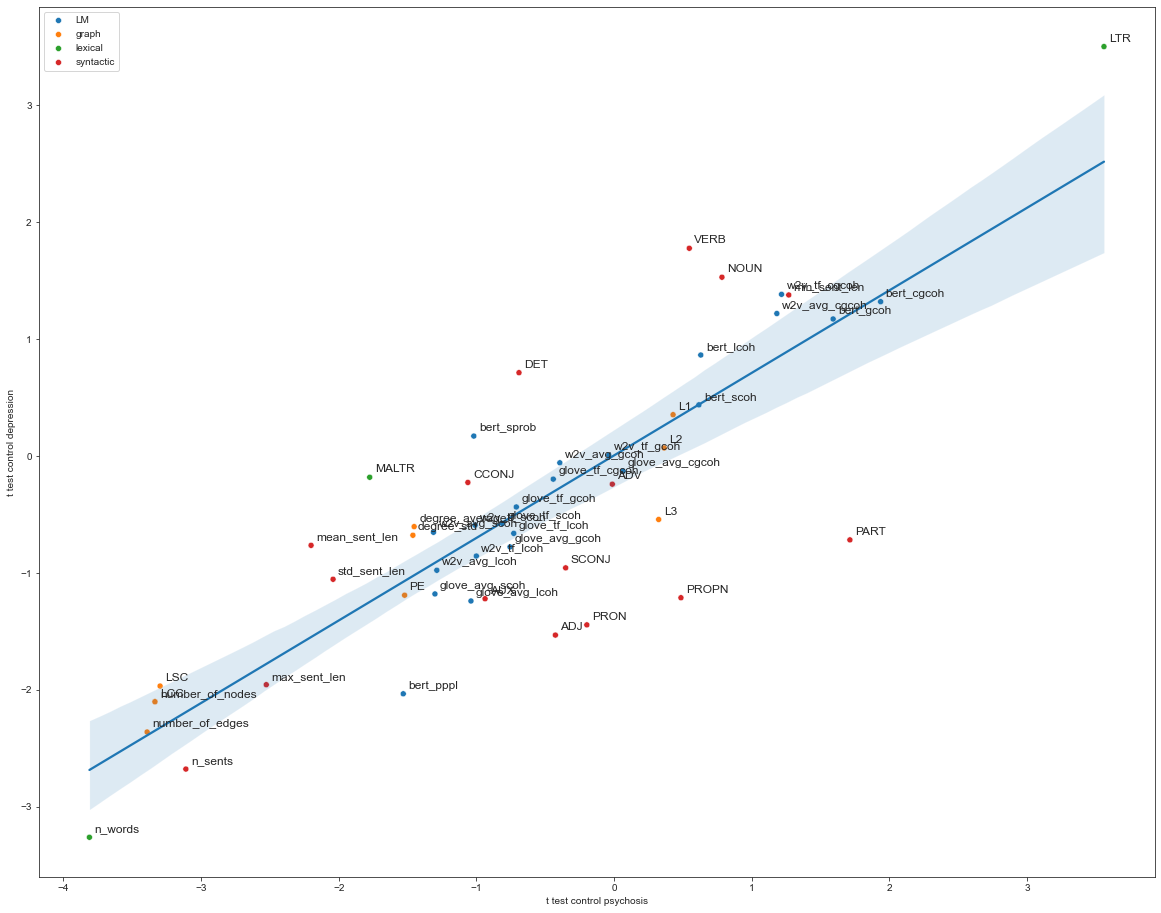

In [101]:
fig, ax = plt.subplots(figsize=(20, 16))
sns.scatterplot(x=tru["median"].values, y=tdru["median"].values, ax=ax, hue=tru["metric_group"].values)
sns.regplot(x=tru["median"], y=tdru["median"], ax=ax, scatter=False)
# add lables for each dot from tru['metric_name']
for i in range(len(tru)):
    ax.annotate(tru['metric_name'].iloc[i],  # Text label
                (tru["median"].iloc[i], tdru["median"].iloc[i]),  # Point to label
                xytext=(5, 5),  # Offset from point
                textcoords='offset points',  # Offset units
                fontsize=12)  # Text size
ax.set_xlabel('t test control psychosis')
ax.set_ylabel('t test control depression')
plt.show()

### Group difference pair-wise metrics (t, auc, llh)

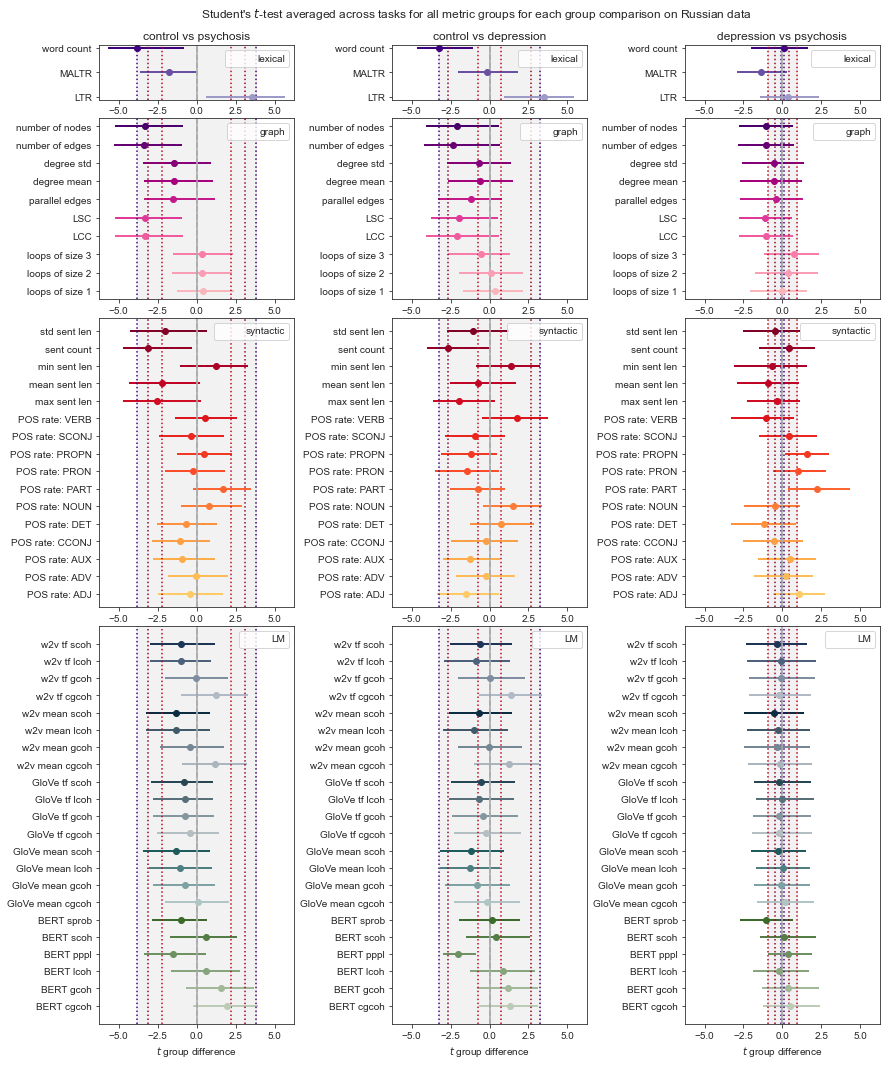

In [102]:
fig, axes = plt.subplots(4, 3, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.5)

lang_ = 'ru'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, suffix in enumerate(["", "_dep", "_sz_dep"]):
        ax = axes[i, j]
        scale = 'group_diff' + suffix
        data = get_data(task_mean_df, lang_, 'mean', metric_group, scale=scale, performance_metric='t')
        unikey = data['unikey'].values[0]
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, task_mean_df, lang_, 'mean', scale=scale, performance_metric='t')
        add_grey(ax, r=max_abs_baseline(task_mean_df, lang_, 'mean', unikey=unikey))
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(gd_name_map[scale])
        if i == 3:
            ax.set_xlabel("$t$ group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle("Student's $t$-test averaged across tasks for all metric groups for each group comparison on Russian data", y=0.91)
plt.savefig(f'{PATH_FIG}{lang_}_t-test_mean_task_all_metrics_across_languages_3_group_comparisons.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [103]:
task_mean_df.performance_metric.unique()

array(['r', 'r2', 'r2_diff', 'r_marginal', 't', 'auc', 'llh', 'llh_diff',
       'llh_marginal_diff'], dtype=object)

In [104]:
max_abs_baseline(task_mean_df, 'ru', 'mean', unikey=unikey)

0.9393351460623706

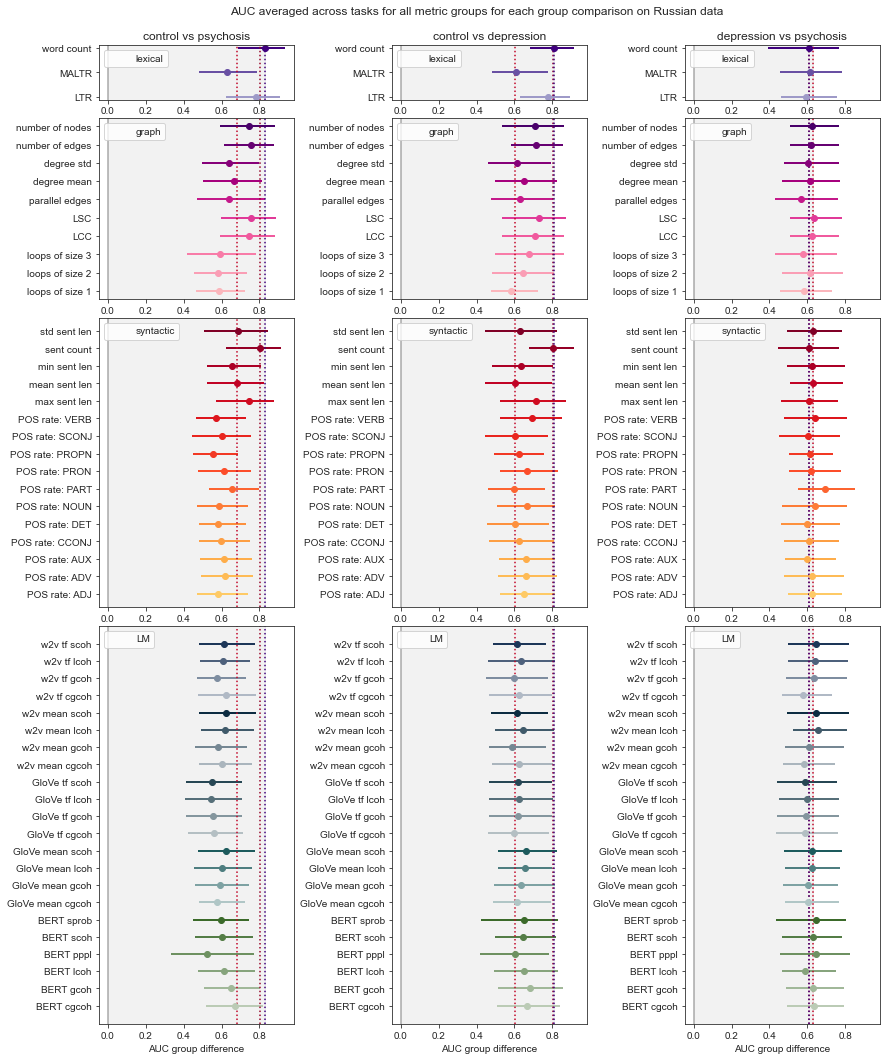

In [105]:
fig, axes = plt.subplots(4, 3, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.5)

pm = 'auc'
lang_ = 'ru'
task = 'mean'
pm_label = 'AUC'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, suffix in enumerate(["", "_dep", "_sz_dep"]):
        ax = axes[i, j]
        scale = 'group_diff' + suffix
        data = get_data(task_mean_df, lang_, task, metric_group, scale=scale, performance_metric=pm)
        unikey = data['unikey'].values[0]
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, task_mean_df, lang_, task, scale=scale, performance_metric=pm, add_neg=False)
        ax.axvspan(0, max_abs_baseline(task_mean_df, lang_, task, unikey=unikey), color='grey', alpha=0.1)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(gd_name_map[scale])
        if i == 3:
            ax.set_xlabel(f"{pm_label} group difference")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=2)

fig.suptitle(f"{pm_label} averaged across tasks for all metric groups for each group comparison on Russian data", y=0.91)
plt.savefig(f'{PATH_FIG}{lang_}_{pm}_mean_task_all_metrics_across_languages_3_group_comparisons.png', dpi=300, bbox_inches = 'tight')
plt.show()

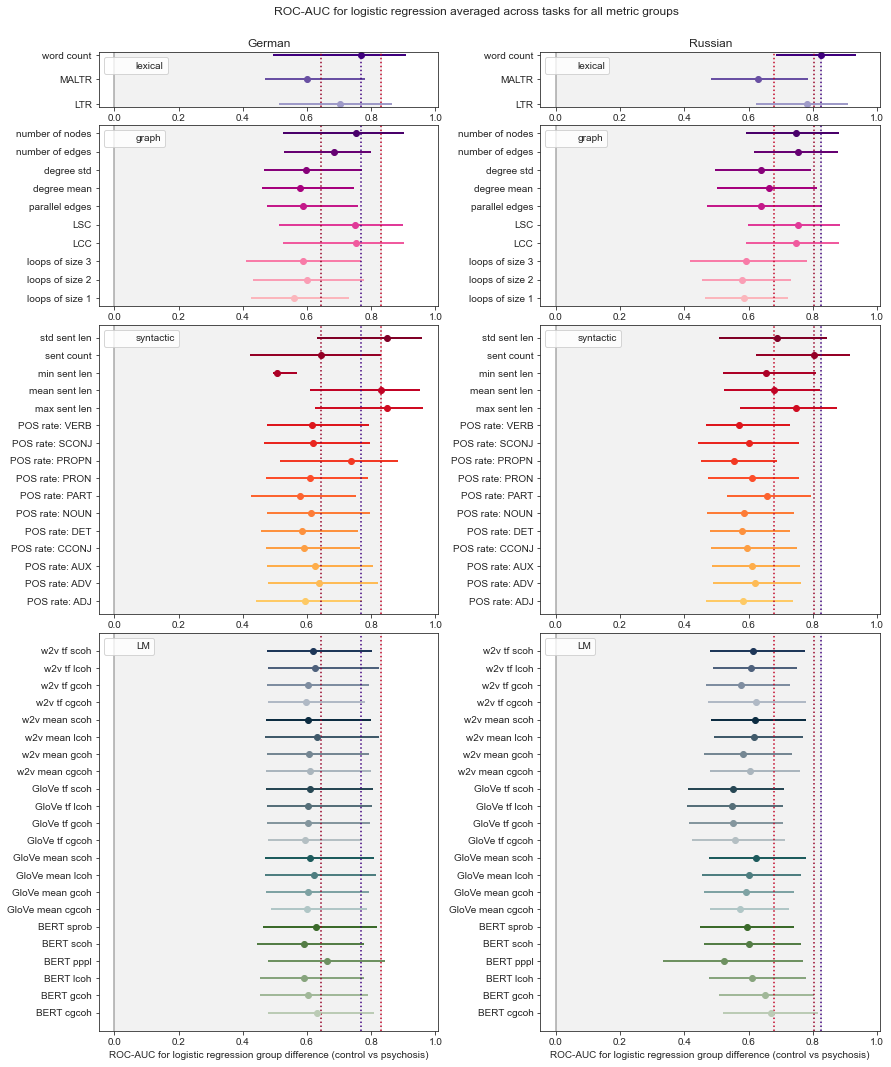

In [106]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

pm = 'auc'
scale = 'group_diff'
task = 'mean'
pm_label = 'ROC-AUC for logistic regression'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        data = get_data(task_mean_df, lang, task, metric_group, scale=scale, performance_metric=pm)
        unikey = data['unikey'].values[0]
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, task_mean_df, lang, task, scale=scale, performance_metric=pm, add_neg=False)
        ax.axvspan(0, max_abs_baseline(task_mean_df, lang, task, unikey=unikey), color='grey', alpha=0.1)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        if i == 3:
            ax.set_xlabel(f"{pm_label} group difference (control vs psychosis)")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=2)

fig.suptitle(f"{pm_label} averaged across tasks for all metric groups", y=0.915);
plt.savefig(f'{PATH_FIG}{pm}_mean_task_all_metrics_across_languages.png', dpi=300, bbox_inches = 'tight')
plt.show()

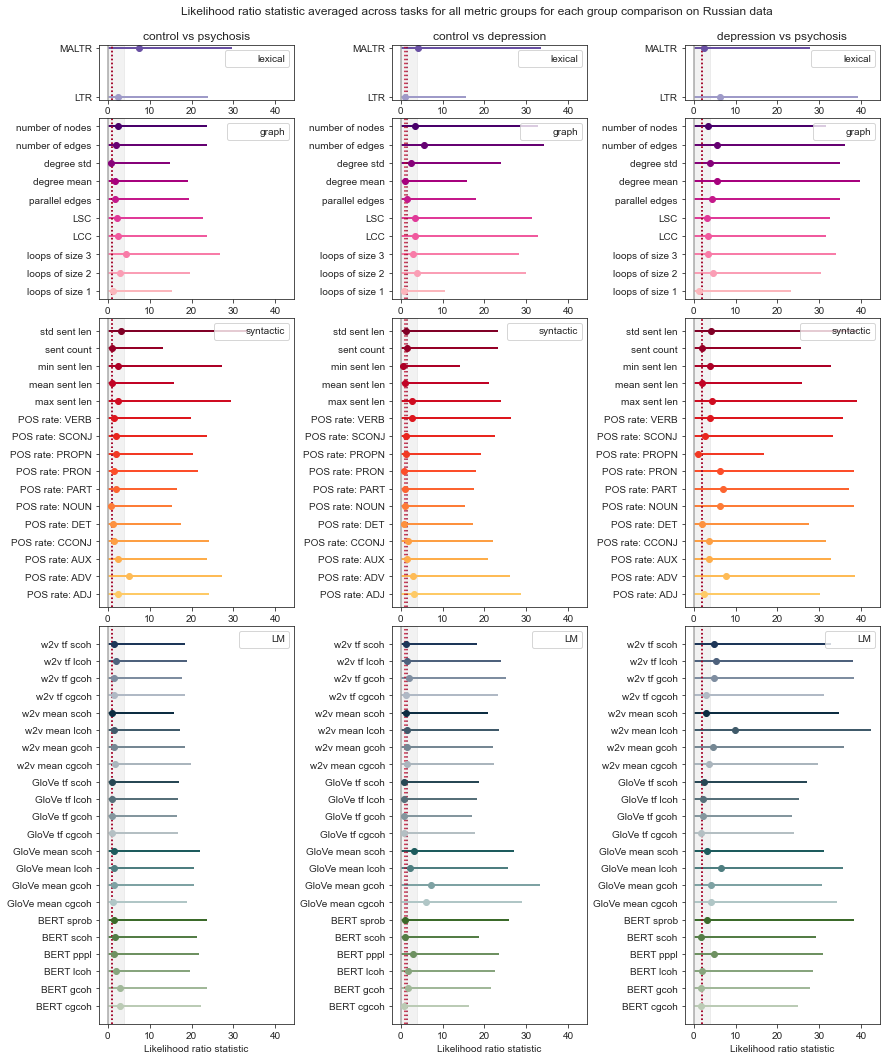

In [107]:
fig, axes = plt.subplots(4, 3, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.5)

pm = 'llh_diff'
scale = 'group_diff'
task = 'mean'
pm_label = 'Likelihood ratio statistic'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, suffix in enumerate(["", "_dep", "_sz_dep"]):
        ax = axes[i, j]
        scale = 'group_diff' + suffix
        data = get_data(task_mean_df, lang_, task, metric_group, scale=scale, performance_metric=pm)
        unikey = data['unikey'].values[0]
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, task_mean_df, lang_, task, scale=scale, performance_metric=pm, add_neg=False)
        ax.axvspan(0, P_LLR, color='grey', alpha=0.1)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(gd_name_map[scale])
        if i == 3:
            ax.set_xlabel(pm_label)
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle(f"{pm_label} averaged across tasks for all metric groups for each group comparison on Russian data", y=0.91)
plt.savefig(f'{PATH_FIG}{lang_}_{pm}_mean_task_all_metrics_across_languages_3_group_comparisons.png', dpi=300, bbox_inches = 'tight')
plt.show()

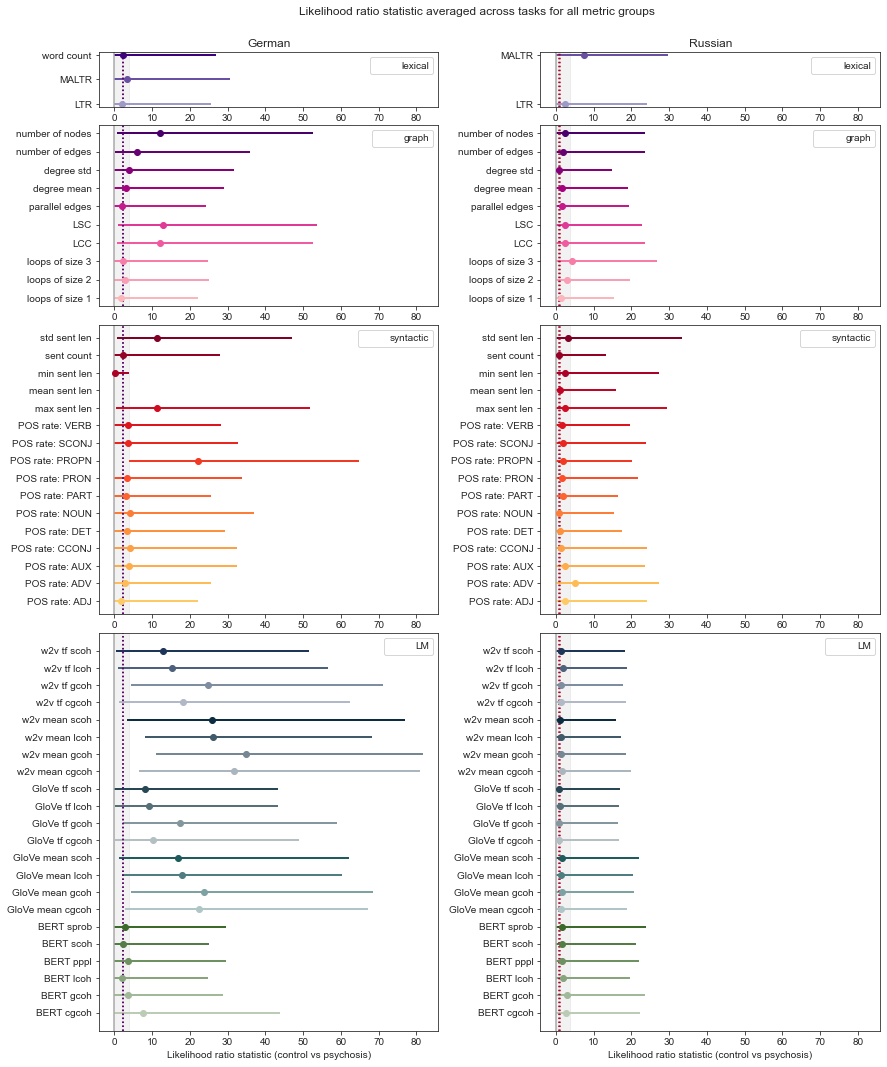

In [108]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 10, 16, 22]})
plt.subplots_adjust(hspace=0.08, wspace=0.3)

pm = 'llh_diff'
scale = 'group_diff'
task = 'mean'
pm_label = 'Likelihood ratio statistic'
for i, metric_group in enumerate(['lexical', 'graph', 'syntactic', 'LM']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        data = get_data(task_mean_df, lang, task, metric_group, scale=scale, performance_metric=pm)
        unikey = data['unikey'].values[0]
        plot_horisontal_ci_ax(data, ax, palette=metric_to_color, xlabel=None)
        add_control_lines(ax, task_mean_df, lang, task, scale=scale, performance_metric=pm, add_neg=False)
        ax.axvspan(0, P_LLR, color='grey', alpha=0.1)
        ax.xaxis.set_tick_params(labelbottom=True)
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        if i == 3:
            ax.set_xlabel(f"{pm_label} (control vs psychosis)")
        ax.plot([], [], ' ', label=metric_group)
        ax.legend(loc=1)

fig.suptitle(f"{pm_label} averaged across tasks for all metric groups", y=0.915);
plt.savefig(f'{PATH_FIG}{pm}_mean_task_all_metrics_across_languages.png', dpi=300, bbox_inches = 'tight')
plt.show()

## Correlation of incremental value with performance

In [109]:
def min_e(flt):
    for i in range(2, 10):
        thr = float(f"10e-{i}")
        if flt > thr:
            return f"10e-{i}"
    return f"10e-10"

In [110]:
def get_coefficient_r_p(x_name, y_name, x, y):
    df = pd.DataFrame({x_name: x, y_name: y})
    df.dropna(inplace=True)
    r, p = stats.pearsonr(df[x_name], df[y_name])
    print(f'{x_name}, {y_name}, {r:.2f}, {p:.10f}')
    return r, p

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
label_thresholds = {
    "ru": [0.08, 0.06],
    "de": [0.1, 0.045]
}
           
for i, lang_ in enumerate(['de', 'ru']):
    ax = axes[i]
    panss_total_r_data = get_data(task_mean_df, lang_, 'mean', unikey='panss_total_r_single')
    panss_total_r2_diff_data = get_data(task_mean_df, lang_, 'mean', unikey='panss_total_r2_diff_single')
    x = []
    y = []
    
    for metric, color in metric_to_color.items():
        r2 = panss_total_r_data[panss_total_r_data['metric_name'] == metric]['median'].values[0] ** 2
        r2_diff = panss_total_r2_diff_data[panss_total_r2_diff_data['metric_name'] == metric]['median'].values[0]
        if pd.isna(r2) or pd.isna(r2_diff):
            continue
        ax.scatter([r2], [r2_diff], color=color)
        if r2 > label_thresholds[lang_][0] or r2_diff > label_thresholds[lang_][1]:
            if metric == 'LCC':
                ax.annotate(metric, (r2, r2_diff-0.002), textcoords="offset points", xytext=(5, 5), fontsize=8)
            else:
                ax.annotate(metric, (r2, r2_diff), textcoords="offset points", xytext=(5, 5), fontsize=8)
        x.append(r2)
        y.append(r2_diff)
    sns.regplot(y=y, x=x, ci=None, scatter=False, color='grey', ax=ax)
    ax.set_xlabel('r squared (PANSS total)')
    ax.set_ylabel('r squared difference (PANSS total)')
    ax.set_title(f"Russian" if lang_ == "ru" else "German")
    coef, p = get_coefficient_r_p(lang_ + '_r2', lang_ +'_r2_diff', x, y)
    p_str = f"$p$>{p:.2f}" if p >= 0.01 else f"$p$>{min_e(p)}"
    ax.yaxis.set_tick_params(labelbottom=True)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.text(0.07, 0.95,
            f'$r$={coef:.2f}, ' + p_str, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8)) 
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    lo = min(xlim[0], ylim[0])
    hi = max(xlim[1], ylim[1])
    ax.fill_between([lo, hi], [lo, hi], [hi, hi], alpha=0.1, color='gray')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

de_r2, de_r2_diff, 0.76, 0.0000000001
ru_r2, ru_r2_diff, 0.22, 0.1199745468


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
label_thresholds = {
    "ru": [10, 3],
    "de": [10, 30]
}
for i, lang_ in enumerate(['de', 'ru']):
    ax = axes[i]
    panss_total_r_data = get_data(task_mean_df, lang_, 'mean', unikey='group_diff_llh_marginal_diff_single')
    panss_total_r2_diff_data = get_data(task_mean_df, lang_, 'mean', unikey='group_diff_llh_diff_single')
    x = []
    y = []
    
    for metric, color in metric_to_color.items():
        r2 = panss_total_r_data[panss_total_r_data['metric_name'] == metric]['median'].values[0]
        r2_diff = panss_total_r2_diff_data[panss_total_r2_diff_data['metric_name'] == metric]['median'].values[0] * 2
        if pd.isna(r2) or pd.isna(r2_diff):
            continue
        ax.scatter([r2], [r2_diff], color=color)
        if r2 > label_thresholds[lang_][0] or r2_diff > label_thresholds[lang_][1]:
            ax.annotate(metric, (r2, r2_diff), textcoords="offset points", xytext=(5, 5), fontsize=8)
        x.append(r2)
        y.append(r2_diff)
    sns.regplot(y=y, x=x, ci=None, scatter=False, color='grey', ax=ax)
    ax.set_xlabel('likelihood ratio statistic vs null')
    ax.set_ylabel('likelihood ratio statistic vs baseline')
    ax.set_title(f"Russian" if lang_ == "ru" else "German")
    coef, p = get_coefficient_r_p(lang_ + '_r2', lang_ +'_r2_diff', x, y)
    p_str = f"$p$>{p:.2f}" if p >= 0.01 else f"$p$>{min_e(p)}"
    ax.yaxis.set_tick_params(labelbottom=True)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.text(0.04, 0.08,
            f'$r$={coef:.2f}, ' + p_str, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8)) 
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    lo = min(xlim[0], ylim[0])
    hi = max(xlim[1], ylim[1])
    ax.fill_between([lo, hi], [lo, hi], [hi, hi], alpha=0.1, color='gray')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

## Correlation of performance with correlation with verbosity

each language, each task: 3 baselines by 2 t-test and panss total performance - scatter plot + correlation line: performace vs corr baseline - color metrics by group

In [ ]:
def corr_nan(df, col1, col2, abs_=True):
    dropped_c = df.dropna(subset=[col1, col2])
    c1 = abs(dropped_c[col1]) if abs_ else dropped_c[col1]
    c2 = abs(dropped_c[col2]) if abs_ else dropped_c[col2]
    r_c = stats.pearsonr(c1, c2)[0]
    return r_c

In [ ]:
def get_coefficient(x_name, y_name, x, y):
    df = pd.DataFrame({x_name: x, y_name: y})
    df.dropna(inplace=True)
    r, p = stats.pearsonr(df[x_name], df[y_name])
    print(f'{x_name}, {y_name}, {r:.2f}, {p:.5f}')
    return r

In [ ]:
control_name_map = {
    "n_sents": "sentence count",
    "n_words": "word count",
    "mean_sent_len": "mean sentence length"
}

In [ ]:
# lang="ru"
# fig, axes = plt.subplots(3, 2, figsize=(14, 18), sharex=True)
# plt.subplots_adjust(hspace=0.08) #, wspace=0.3)

# for i, control_col in  enumerate(control_cols):
#     for j, scale in enumerate(['panss_total', 'group_diff']):
#         ax = axes[i, j]
#         if i == 0:
#             ax.set_title(scale)
#         task = best_task[lang]
#         for metric_group in ['lexical', 'graph', 'syntactic', 'LM']:
#             pm = 't' if scale == 'group_diff' else "r"
#             data = get_data(long_df, lang, task, metric_group, scale=scale, performance_metric=pm)
#             data = data[data["metric_name"] != control_col]
#             sns.regplot(y=abs(data['median']), x=abs(data[f'corr_{control_col}_median']), 
#                         color=group_to_color[metric_group], ax=ax, ci=None)
# #         data = get_data(long_df, lang, task, scale='group_diff')
# #         data = data[data["metric_name"] != control_col]
# #         sns.regplot(y=abs(data['median']), x=abs(data[f'corr_{control_col}_median']), ax=ax, ci=None)
# fig.suptitle(lang, y=0.9);

In [ ]:
lang = "ru"
fig, axes = plt.subplots(3, 2, figsize=(14, 18), sharex=True)
plt.subplots_adjust(hspace=0.08) #, wspace=0.3)

for i, control_col in  enumerate(control_cols):
    for j, scale in enumerate(['panss_total', 'group_diff']):
        ax = axes[i, j]
        if i == 0:
            ax.set_title(scale)
        task = best_task[lang]
        pm = 't' if scale == 'group_diff' else "r"
        data = get_data(long_df, lang, task, scale=scale, performance_metric=pm)
        data = data[(data["metric_name"] != control_col) & data.apply(perfrom_above_threshold, axis=1)]
        sns.regplot(y=abs(data['median']), x=abs(data[f'corr_{control_col}_median']), ax=ax, ci=None)
fig.suptitle(lang, y=0.9);

In [ ]:
# lang = "de"
# fig, axes = plt.subplots(3, 2, figsize=(14, 18), sharex=True)
# plt.subplots_adjust(hspace=0.08) #, wspace=0.3)

# for i, control_col in  enumerate(control_cols):
#     for j, scale in enumerate(['panss_total', 'group_diff']):
#         ax = axes[i, j]
#         task = best_task[lang]
#         for metric_group in ['lexical', 'graph', 'syntactic', 'LM']:
#             pm = 't' if scale == 'group_diff' else "r"
#             data = get_data(long_df, lang, task, metric_group, scale=scale, performance_metric=pm)
#             data = data[data["metric_name"] != control_col]
#             sns.regplot(y=abs(data['median']), x=abs(data[f'corr_{control_col}_median']), 
#                         color=group_to_color[metric_group], ax=ax, ci=None)
#             if i == 0:
#                 ax.set_title(scale)
# #         data = get_data(long_df, lang, task, scale='group_diff')
# #         data = data[data["metric_name"] != control_col]
# #         sns.regplot(y=abs(data['median']), x=abs(data[f'corr_{control_col}_median']), ax=ax, ci=None)
# fig.suptitle(lang, y=0.9);

In [ ]:
lang = "de"
fig, axes = plt.subplots(3, 2, figsize=(14, 18), sharex=True)
plt.subplots_adjust(hspace=0.08) #, wspace=0.3)

for i, control_col in  enumerate(control_cols):
    for j, scale in enumerate(['panss_total', 'group_diff']):
        pm = 't' if scale == 'group_diff' else "r"
        data = get_data(long_df, lang, task, scale=scale, performance_metric=pm)
        ax = axes[i, j]
        if i == 0:
            ax.set_title(scale)
        task = best_task[lang]
        data = data[(data["metric_name"] != control_col) & data.apply(perfrom_above_threshold, axis=1)]
        sns.regplot(y=abs(data['median']), x=abs(data[f'corr_{control_col}_median']), ax=ax, ci=None)
fig.suptitle(lang, y=0.9);

### Correlation with verbosity against performance

In [ ]:
de_tasks = long_df[long_df["lang"] == "de"]['task'].unique()
ru_tasks = long_df[long_df["lang"] == "ru"]['task'].unique()

In [ ]:
scale = "panss_total"
for lang in ['de', 'ru']:
    fig, axes = plt.subplots(3, 5, figsize=(36, 18), sharex=True, sharey=True)
    plt.subplots_adjust(hspace=0.13) #, wspace=0.3)
    for i, control_col in  enumerate(control_cols):
        ax = axes[i, 0]
        task = "mean"
        if i == 0:
            ax.set_title(task)
        data = get_data(task_mean_df, lang, task, scale=scale)
        data = data[(data["metric_name"] != control_col)]
        color = data.apply(perfrom_above_threshold, axis=1)
        y_name, x_name = f"corr_{control_col}_median_abs", f"median"
        y, x = abs(data['median']), abs(data[f'corr_{control_col}_median'])
        sns.regplot(y=y, x=x, ci=None, scatter=False, color='grey', ax=ax)
        sns.scatterplot(y=y, x=x, ax=ax)
        ax.set_ylabel("median r averaged per task")
        coef, p = get_coefficient_r_p(x_name, y_name, x, y)
        p_str = f"$p$>{p:.2f}" if p >= 0.01 else f"$p$>{min_e(p)}"
        ax.yaxis.set_tick_params(labelbottom=True)
        ax.xaxis.set_tick_params(labelbottom=True)
        ax.text(0.04, 0.08,
                f'$r$={coef:.2f}, ' + p_str, transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8)) 
        for j, task in enumerate(de_tasks if lang == "de" else ru_tasks):
            ax = axes[i, j+1]
            if i == 0:
                ax.set_title(task)
            data = get_data(long_df, lang, task, scale=scale)
            data = data[(data["metric_name"] != control_col)]
            color = data.apply(perfrom_above_threshold, axis=1)
            y_name, x_name = f"corr_{control_col}_median", f"median"
            y, x = abs(data['median']), abs(data[f'corr_{control_col}_median'])
            sns.regplot(y=y, x=x, ci=None, scatter=False, color='grey', ax=ax)
            sns.scatterplot(y=y, x=x, ax=ax)
            ax.set_ylabel(f"median r on {task} task")
            ax.yaxis.set_tick_params(labelleft=True)
            ax.xaxis.set_tick_params(labelbottom=True)
            coef, p = get_coefficient_r_p(x_name, y_name, x, y)
            p_str = f"$p$>{p:.2f}" if p >= 0.01 else f"$p$>{min_e(p)}"
            ax.text(0.04, 0.08,
                    f'$r$={coef:.2f}, ' + p_str, transform=ax.transAxes,
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
        fig.suptitle(f"Correlation with verbosity vs performance across tasks ({lang})", y=0.92);


In [ ]:
# NO metric group differentiation figure

scale = "panss_total"
fig, axes = plt.subplots(3, 2, figsize=(14, 18), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.13) #, wspace=0.3)

for i, control_col in  enumerate(control_cols):
    for j, lang in enumerate(['de', 'ru']):
        ax = axes[i, j]
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        task = "mean"
        data = get_data(task_mean_df, lang, task, scale=scale)
        data = data[(data["metric_name"] != control_col)]
#         color = data.apply(perfrom_above_threshold, axis=1)
        y_name, x_name = f"corr_{control_col}_median_abs", f"median"
        y, x = abs(data['median']), abs(data[f'corr_{control_col}_median'])
        

        sns.regplot(y=y, x=x, ci=None, scatter=False, color='grey', ax=ax)
        sns.scatterplot(y=y, x=x, ax=ax)
        
        
        ax.yaxis.set_tick_params(labelleft=True)
        ax.xaxis.set_tick_params(labelbottom=True)
        ax.set_ylabel("$r$ symptom severity correlation")
        ax.set_xlabel(control_name_map[control_col])
        
        coef, p = get_coefficient_r_p(x_name, y_name, x, y)
        p_str = f"$p$>{p:.2f}" if p >= 0.01 else f"$p$>{min_e(p)}"
        ax.text(0.04, 0.08,
                f'$r$={coef:.2f}, ' + p_str, transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
fig.suptitle("Correlation with verbosity vs median correlation with PANSS total averaged across tasks (absolute values)", y=0.92);
plt.savefig(f'{PATH_FIG}verbosity_correlation_performance_avergae.png', dpi=300, bbox_inches = 'tight')
fig.show();

## Best metrics perform across tasks
difference between tasks: SD(performance) / (mean task performance) - scatter vs mean task performance on t-test and panss total - color metrics by group

In [ ]:
def diff_task_performance(df, metric_name, lang, unikey):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['unikey'] == unikey)]['median'].abs()
    return np.std(data) / np.mean(data)

In [ ]:
def best_task_performance(df, metric_name, lang, unikey):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['unikey'] == unikey)]['median'].abs()
    return np.nanmax(data)

In [ ]:
dict_diff = {"metric_group": [], 
             "metric_name": [], 
             "diff_group_diff_de": [], "diff_group_diff_ru": [], 
             "diff_panss_total_de": [], "diff_panss_total_ru": [],
#              "diff_ps_r_dep.severity_ru": [],
             
             "group_diff_de": [], "group_diff_ru": [], 
             "panss_total_de": [], "panss_total_ru": [],
#              "ps_r_dep.severity_ru": [], 
             
             "best_group_diff_de": [], "best_group_diff_ru": [], 
             "best_panss_total_de": [], "best_panss_total_ru": [],
#              "best_ps_r_dep.severity_ru": []
            }
slice_df = long_df[long_df['metric_group'] != "overview"]
for lang in ["de", "ru"]:
    for metric_name in metric_to_color:
        for unikey in ['panss_total_r_single', 'group_diff_t_single']: # , "ps_r_dep.severity_ps_r_single"
#             if lang == 'de' and unikey == "ps_r_dep.severity_ps_r_single" : 
#                 continue
            
            diff = diff_task_performance(slice_df, metric_name, lang, unikey)
            mean = mean_task_performance(slice_df, metric_name, lang, unikey)
            best = best_task_performance(slice_df, metric_name, lang, unikey)
            scale = long_df[long_df['unikey'] == unikey]['scale'].values[0]
            dict_diff[f"diff_{scale}_{lang}"].append(diff)
            if lang == "ru" and unikey == "group_diff_t_single":
                dict_diff[f"metric_name"].append(metric_name)
                dict_diff["metric_group"].append(slice_df[slice_df['metric_name'] == metric_name]["metric_group"].values[0])
            dict_diff[f"{scale}_{lang}"].append(mean)
            dict_diff[f"best_{scale}_{lang}"].append(best)

In [ ]:
diff_df = pd.DataFrame.from_dict(dict_diff)
diff_df = diff_df.set_index('metric_name')

In [ ]:
diff_df["diff_group_diff_de"].mean()

In [ ]:
diff_df["diff_group_diff_ru"].mean()

In [ ]:
diff_df["diff_panss_total_de"].mean()

In [ ]:
diff_df["diff_panss_total_ru"].mean()

In [ ]:
slice_diff_df = diff_df[[f"diff_panss_total_de", f"panss_total_de"]]

In [ ]:
# def get_coefficient(x_name, y_name, x, y):
#     df = pd.DataFrame({x_name: x, y_name: y})
#     df = sm.add_constant(df, prepend=False)
#     mod = sm.OLS(df[y_name], df[x_name])
#     res = mod.fit()
#     print(f'{x_name}, {y_name}, {res.rsquared:.2f}, {res.pvalues[x_name]:.5f}')
# #     print(res.summary())
#     return res.rsquared

In [ ]:
get_coefficient(f"panss_total_de", f"diff_panss_total_de", diff_df[f"panss_total_de"], diff_df[f"diff_panss_total_de"])

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(6, 12))
for i, scale in enumerate(['panss_total', 'group_diff']): # , 'ps_r_dep.severity'
    lang = 'ru'
    ax = axes[i]
    if i == 0:
        ax.set_title(f"Russian" if lang == "ru" else "German")
    y_name, x_name = f"diff_{scale}_{lang}", f"{scale}_{lang}"
    y, x = diff_df[y_name], diff_df[x_name]
    sns.scatterplot(y=y, x=x, hue=diff_df["metric_group"], ax=ax, palette=group_to_color)
    sns.regplot(y=y, x=x, 
                ci=None, scatter=False, color='grey', ax=ax)
    ax.set_ylabel('coefficient of variation')
    label = {'panss_total': 'mean $r$ PANSS total',
             'group_diff': "mean $t$",
             'ps_r_dep.severity': 'mean depression pseudo $r^2$'}.get(scale, '...')
    coef = get_coefficient(x_name, y_name, x, y)
    ax.text(0.04, 0.08,
            f'$r$={coef:.2f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
    ax.set_xlabel(label)
fig.suptitle("Mean performance across tasks vs coefficient of variation in performance across tasks", y=0.925);
# plt.savefig(f'{PATH_FIG}performance_vs_CV_across_tasks.png', dpi=dpi, bbox_inches = 'tight')

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for i, scale in enumerate(['panss_total', 'group_diff']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        y_name, x_name = f"diff_{scale}_{lang}", f"{scale}_{lang}"
        y, x = diff_df[y_name], diff_df[x_name]
        sns.scatterplot(y=y, x=x, hue=diff_df["metric_group"], ax=ax, palette=group_to_color)
        sns.regplot(y=y, x=x, 
                    ci=None, scatter=False, color='grey', ax=ax)
        coef = get_coefficient(x_name, y_name, x, y)
        ax.text(0.04, 0.08,
                f'$r$={coef:.2f}', transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
        ax.set_ylabel('coefficient of variation')
        label = '$r$ symptom severity correlation (PANSS totals score)' if i == 0 else "$t$ group difference"
        ax.set_xlabel(label)
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
fig.suptitle("Mean performance across tasks vs coefficient of variation in performance across tasks", y=0.925);
plt.savefig(f'{PATH_FIG}performance_vs_CV_across_tasks.png', dpi=dpi, bbox_inches = 'tight')

#### for overview

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
scale = 'panss_total'

for j, lang in enumerate(["de", "ru"]):
    ax = axes[j]
    y_name, x_name = f"diff_{scale}_{lang}", f"{scale}_{lang}"
    y, x = diff_df[y_name], diff_df[x_name]
    sns.scatterplot(y=y, x=x, hue=diff_df["metric_group"], ax=ax, palette=group_to_color, legend=False, s=200, rasterized=True)
    sns.regplot(y=y, x=x, ci=None, scatter=False, color='#292929', ax=ax, line_kws={'linewidth':6, 'alpha': 0.7})
    coef = get_coefficient(x_name, y_name, x, y)
    ax.set_ylabel('')
    ax.set_xlabel('', fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])
    [x.set_linewidth(1.5) for x in ax.spines.values()]
# fig.suptitle("Mean performance across tasks vs coefficient of variation in performance across tasks", y=0.925);
plt.savefig(f'{PATH_FIG}performance_vs_CV_for_overview.svg', dpi=dpi, bbox_inches = 'tight', transparent=True)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for i, scale in enumerate(['panss_total', 'group_diff']):
    for j, lang in enumerate(["de", "ru"]):
        ax = axes[i, j]
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        y_name, x_name = f"diff_{scale}_{lang}", f"best_{scale}_{lang}"
        y, x = diff_df[y_name], diff_df[x_name]
        sns.scatterplot(y=y, x=x, hue=diff_df["metric_group"], ax=ax, palette=group_to_color)
        sns.regplot(y=y, x=x, 
                    ci=None, scatter=False, color='grey', ax=ax)
        ax.set_ylabel('coefficient of variation')
        coef = get_coefficient(x_name, y_name, x, y)
        ax.text(0.04, 0.08,
                f'$r$={coef:.2f}', transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
        label = 'best $r^2$ PANSS total' if i == 0 else "best $t$"
        ax.set_xlabel(label)
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
fig.suptitle("Best performance across tasks vs coefficient of variation in performance across tasks", y=0.925);
plt.savefig(f'{PATH_FIG}best_performance_vs_CV_across_tasks.png', dpi=dpi, bbox_inches = 'tight')

## Best metrics perform across scales
difference between scales: SD(performance) / (mean scale performance) - scatter vs mean scale performance on t-test and - color metrics by group

normalize each scale performance z transform ((val) - mean(vals)) / std(vals)

In [ ]:
long_df["scale"].unique()

In [ ]:
def normalize_scale_values(df, unikey, lang, task):
    data = df[(df['lang'] == lang) & (df['unikey'] == unikey) & (df['task'] == task)]['median'].values
    return (data - np.nanmean(data)) / np.nanstd(data)

In [ ]:
long_df["normalized_median"] = np.nan

In [ ]:
for lang in ["de", "ru"]:
    for task in long_df[long_df["lang"] == lang]["task"].unique():
        for unikey in ['panss_pos_r_single', 'panss_neg_r_single', 'panss_o_r_single', 'panss_total_r_single', 
                       'group_diff_t_single']:
            vals = normalize_scale_values(long_df, unikey, lang, task)
            long_df.loc[(long_df["lang"] == lang) 
                    & (long_df["task"] == task) 
                    & (long_df["unikey"] == unikey), "normalized_median"] = vals

In [ ]:
def diff_scale_performance(df, metric_name, lang, task):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['task'] == task)]['normalized_median'].abs()
    return np.nanstd(data) / np.nanmean(data)

In [ ]:
def mean_scale_performance(df, metric_name, lang, task):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['task'] == task)]['normalized_median'].abs()
    return np.nanmean(data)

In [ ]:
def max_scale_performance(df, metric_name, lang, task):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name) & (df['task'] == task)]['normalized_median'].abs()
    return np.nanmax(data)

In [ ]:
def diff_max_mean_task_scale_performance(df, metric_name, lang):
    data = df[(df['lang'] == lang) & (df['metric_name'] == metric_name)]
    ress = []
    for task in data['task'].unique():
        ress.append(np.nanmean(data[data['task'] == task]['normalized_median'].abs()))
    return np.nanstd(ress) / np.nanmean(ress), np.nanmax(ress), np.nanmean(ress)

In [ ]:
dict_diff_ = {"metric_group": [],
              "metric_name": [],
             'diff_de': [], 'diff_ru': [],
             'best_perf_de': [], 'best_perf_ru': [],
              'perf_de': [], 'perf_ru': []
             }


for lang in ["de", "ru"]:
    for metric_name in metric_to_color:
        diff, best, mean = diff_max_mean_task_scale_performance(long_df, metric_name, lang)
        if lang == "de":
            dict_diff_["metric_name"].append(metric_name)
            dict_diff_["metric_group"].append(long_df[long_df['metric_name'] == metric_name]["metric_group"].values[0])
        dict_diff_[f"diff_{lang}"].append(diff)
        dict_diff_[f"best_perf_{lang}"].append(best)
        dict_diff_[f"perf_{lang}"].append(mean)

In [ ]:
diff_df_ = pd.DataFrame.from_dict(dict_diff_)
diff_df_.set_index("metric_name")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for j, lang in enumerate(["de", "ru"]):
    task = long_df[long_df["lang"] == lang]["task"].unique()
    ax = axes[j]
    ax.set_title(f"Russian" if lang == "ru" else "German")
    y_name, x_name = f"diff_{lang}", f"perf_{lang}"
    y, x = diff_df_[y_name], diff_df_[x_name]
    sns.scatterplot(y=y, x=x, hue=diff_df_["metric_group"], ax=ax, palette=group_to_color)
    sns.regplot(y=y, x=x, 
                ci=None, scatter=False, color='grey', ax=ax)
    coef = get_coefficient(x_name, y_name, x, y)
    ax.text(0.04, 0.08,
            f'$r$={coef:.2f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
    ax.set_ylabel('coefficient of variation')
    ax.set_xlabel(f'mean performance')
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
fig.suptitle("Mean performance across normalized scales vs coefficient of variation in performance across normalized scales");
plt.savefig(f'{PATH_FIG}mean_performance_vs_CV_across_normalized_scales_task_averaged.png', dpi=dpi, bbox_inches = 'tight')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for j, lang in enumerate(["de", "ru"]):
    task = long_df[long_df["lang"] == lang]["task"].unique()
    ax = axes[j]
    ax.set_title(f"Russian" if lang == "ru" else "German")
    y_name, x_name = f"diff_{lang}", f"best_perf_{lang}"
    y, x = diff_df_[y_name], diff_df_[x_name]
    sns.scatterplot(y=y, x=x, hue=diff_df_["metric_group"], ax=ax, palette=group_to_color)
    sns.regplot(y=y, x=x, 
                ci=None, scatter=False, color='grey', ax=ax)
    coef = get_coefficient(x_name, y_name, x, y)
    ax.text(0.04, 0.08,
            f'$r$={coef:.2f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
    ax.set_ylabel('coefficient of variation')
    ax.set_xlabel(f'best performance')
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
fig.suptitle("Best performance across normalized scales vs coefficient of variation in performance across normalized scales");
plt.savefig(f'{PATH_FIG}best_performance_vs_CV_across_normalized_scales_task_averaged.png', dpi=dpi, bbox_inches = 'tight')

In [ ]:
dict_diff_ = {"metric_group": [], "metric_name": [], 
             'diff_anger_de': [], 'diff_fear_de': [],
             'diff_happiness_de': [], 'diff_sadness_de': [],
             'diff_adventure_ru': [], 'diff_chair_ru': [],
             'diff_present_ru': [], 'diff_sportsman_ru': [],
             
             'perf_anger_de': [], 'perf_fear_de': [],
             'perf_happiness_de': [], 'perf_sadness_de': [], 
             
             'perf_adventure_ru': [], 'perf_chair_ru': [], 
             'perf_present_ru': [], 'perf_sportsman_ru': [],
             
             'best_perf_anger_de': [], 'best_perf_fear_de': [],
             'best_perf_happiness_de': [], 'best_perf_sadness_de': [], 
             
             'best_perf_adventure_ru': [], 'best_perf_chair_ru': [], 
             'best_perf_present_ru': [], 'best_perf_sportsman_ru': []}


for lang in ["de", "ru"]:
    for metric_name in metric_to_color:
        for task in long_df[long_df["lang"] == lang]["task"].unique():
            diff = diff_scale_performance(long_df, metric_name, lang, task)
            mean = mean_scale_performance(long_df, metric_name, lang, task)
            best = max_scale_performance(long_df, metric_name, lang, task)
            dict_diff_[f"diff_{task}_{lang}"].append(diff)
            if lang == "de" and task == "anger":
                dict_diff_["metric_name"].append(metric_name)
                dict_diff_["metric_group"].append(long_df[long_df['metric_name'] == metric_name]["metric_group"].values[0])
            dict_diff_[f"perf_{task}_{lang}"].append(mean)
            dict_diff_[f"best_perf_{task}_{lang}"].append(best)

In [ ]:
diff_df_ = pd.DataFrame.from_dict(dict_diff_)
diff_df_ = diff_df_.set_index("metric_name")

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
for i in range(4):
    for j, lang in enumerate(["de", "ru"]):
        task = long_df[long_df["lang"] == lang]["task"].unique()[i]
        ax = axes[i, j]
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        y_name, x_name = f"diff_{task}_{lang}", f"perf_{task}_{lang}"
        y, x = diff_df_[y_name], diff_df_[x_name]
        sns.scatterplot(y=y, x=x, hue=diff_df_["metric_group"], ax=ax, palette=group_to_color)
        sns.regplot(y=y, x=x, 
                    ci=None, scatter=False, color='grey', ax=ax)
        coef = get_coefficient(x_name, y_name, x, y)
        ax.text(0.04, 0.08,
                f'$r$={coef:.2f}', transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
        ax.set_ylabel('coefficient of variation')
        ax.set_xlabel(f'mean performance on {task}')
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
fig.suptitle("Mean performance across normalized scales vs coefficient of variation in performance across normalized scales", y=0.91);
plt.savefig(f'{PATH_FIG}performance_vs_CV_across_normalized_scales.png', dpi=dpi, bbox_inches = 'tight')

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
for i in range(4):
    for j, lang in enumerate(["de", "ru"]):
        task = long_df[long_df["lang"] == lang]["task"].unique()[i]
        ax = axes[i, j]
        if i == 0:
            ax.set_title(f"Russian" if lang == "ru" else "German")
        y_name, x_name = f"diff_{task}_{lang}", f"best_perf_{task}_{lang}"
        y, x=diff_df_[y_name], diff_df_[x_name]
        sns.scatterplot(y=y, x=x, hue=diff_df_["metric_group"], ax=ax, palette=group_to_color)
        sns.regplot(y=y, x=x, 
                    ci=None, scatter=False, color='grey', ax=ax)
        coef = get_coefficient(x_name, y_name, x, y)
        ax.text(0.04, 0.08,
                f'$r$={coef:.2f}', transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.8))
        ax.set_ylabel('coefficient of variation')
        ax.set_xlabel(f'best performance on {task}')
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
fig.suptitle("Best performance across normalized scales vs coefficient of variation in performance across normalized scales", y=0.91);
plt.savefig(f'{PATH_FIG}best_performance_vs_CV_across_normalized_scales.png', dpi=dpi, bbox_inches = 'tight')

## Task differences (ICC2)

In [ ]:
long_df[(long_df['lang'] == 'de') & (long_df['unikey'] == 'panss_total_r_single')][long_df[(long_df['lang'] == 'de') & (long_df['unikey'] == 'panss_total_r_single')]['median'].isna()]

In [ ]:
pg.intraclass_corr(data=long_df[(long_df['lang'] == 'de') & (long_df['unikey'] == 'panss_total_r_single')], targets='metric_name', raters='task', ratings='median', nan_policy='omit')

In [ ]:
pg.intraclass_corr(data=long_df[(long_df['lang'] == 'de') & (long_df['unikey'] == 'group_diff_t_single')], targets='metric_name', raters='task', ratings='median', nan_policy='omit')

In [ ]:
pg.intraclass_corr(data=long_df[(long_df['lang'] == 'ru') & (long_df['unikey'] == 'panss_total_r_single')], targets='metric_name', raters='task', ratings='median', nan_policy='omit')

In [ ]:
pg.intraclass_corr(data=long_df[(long_df['lang'] == 'ru') & (long_df['unikey'] == 'group_diff_t_single')], targets='metric_name', raters='task', ratings='median', nan_policy='omit')

#### rank

In [ ]:
ranks = []
metric_names = []
tasks = []
langs = []
scales = []
for lang in ['ru', 'de']:
    for task in long_df[long_df['lang'] == lang]['task'].unique():
        for unikey in ['panss_total_r_single', 'group_diff_t_single']:
            ranks.extend(long_df[(long_df['lang'] == lang) & (long_df['unikey'] == unikey) & (long_df['task'] == task)]['median'].rank().to_list())
            cur_mn = long_df[(long_df['lang'] == lang) & (long_df['unikey'] == unikey) & (long_df['task'] == task)]['metric_name'].to_list()
            
            metric_names.extend(cur_mn)
            langs.extend([lang] * len(cur_mn))
            tasks.extend([task] * len(cur_mn))
            scales.extend([unikey] * len(cur_mn))

In [ ]:
rank_df = pd.DataFrame({'lang':langs, 'unikey': scales, 'task': tasks, 'metric_name': metric_names, 'rank': ranks})

In [ ]:
pg.intraclass_corr(data=rank_df[(rank_df['lang'] == 'de') & (rank_df['unikey'] == 'panss_total_r_single')], targets='metric_name', raters='task', ratings='rank', nan_policy='omit')

In [ ]:
pg.intraclass_corr(data=rank_df[(rank_df['lang'] == 'de') & (rank_df['unikey'] == 'group_diff_t_single')], targets='metric_name', raters='task', ratings='rank', nan_policy='omit')

In [ ]:
pg.intraclass_corr(data=rank_df[(rank_df['lang'] == 'ru') & (rank_df['unikey'] == 'panss_total_r_single')], targets='metric_name', raters='task', ratings='rank', nan_policy='omit')

In [ ]:
pg.intraclass_corr(data=rank_df[(rank_df['lang'] == 'ru') & (rank_df['unikey'] == 'group_diff_t_single')], targets='metric_name', raters='task', ratings='rank', nan_policy='omit')

## Cross task cross language baseline variation

In [ ]:
long_df['scale'].unique()

In [ ]:
boxplot_data = []
for lang in ['ru', 'de']:
    for task in long_df[long_df['lang'] == lang]['task'].unique():
        for unikey in ['panss_pos_r_single', 'panss_neg_r_single', 'panss_o_r_single', 'panss_total_r_single', 
                       'group_diff_t_single']:
            data_slice = long_df[(long_df["task"] == task) & (long_df["lang"] == lang) & (long_df["unikey"] == unikey)]
            mean_performance = data_slice["normalized_median"].abs().mean()
            outperformers = outperform_best_baseline(long_df, lang, task, unikey).to_list()
            boxplot_data.append([lang, task, unikey, mean_performance, len(outperformers)])
#             print(lang, task, scale, mean_performance, len(outperformers))

In [ ]:
boxplot_df = pd.DataFrame(boxplot_data, columns = ["lang", "task", "unikey", "mean_normalized_performance", "outperform_count"])
# sns.boxplot(data=boxplot_df, x="task", y="outperform_count")

In [ ]:
boxplot_df.groupby("lang")["outperform_count"].mean()

In [ ]:
scales_ = ['panss_pos_r_single', 'panss_neg_r_single', 'panss_o_r_single', 'panss_total_r_single', 'group_diff_t_single']
colors_ = ["red", "blue", "gray", "purple", "green",  ]
sc_to_c = dict(zip(scales_, colors_))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
plt.subplots_adjust(wspace=0.08)
for i, lang in enumerate(["de", "ru"]):
    ax = axes[i]
    data = boxplot_df[boxplot_df["lang"] == lang]
    mean = boxplot_df.groupby("lang")["outperform_count"].mean()[lang]
    sns.boxplot(ax=ax, data=data, x="task", y="outperform_count", boxprops={'alpha': 0.4})
    sns.stripplot(ax=ax, data=data, x="task", y="outperform_count", hue="unikey", palette=sc_to_c)
    ax.axhline(mean, linestyle=':', label=f"mean = {mean}")
    ax.set_title(f"Russian" if lang == "ru" else "German")
    if i == 0:
        ax.set_ylabel("number of outperforimg metrics")
    ax.legend()

## Particle use

In [ ]:
from collections import Counter

In [ ]:
all_part_ru = set()
all_part_de = set()
data = {'lang': [], 'task': [], 'id': [], 'line_counts': []}
with open('/Users/galina.ryazanskaya/Downloads/thesis?/code?/processed_values/part.tsv') as f:
    for line in f.readlines():
        line_counts = Counter()
        line = line.strip()
        els = line.split('\t')
        id_ = els[0]
        task_ = els[1]
        lang_ = 'de' if ("NET" in id_ or 'manual' in id_) else 'ru'
        set_ = all_part_de if lang_ == 'de' else all_part_ru
        for i in range(2, len(els[2:]), 2):
            if i + 1 < len(els[1:]):
                key, value = els[i], els[i+1]
                if key not in set_:
                    set_.add(key.lower())
                line_counts[key.lower()] += int(value)
        data['lang'].append(lang_)
        data['task'].append(task_)
        data['id'].append(id_)
        data['line_counts'].append(line_counts)

In [ ]:
data_df = data.copy()
del data_df['line_counts']
iddf = pd.DataFrame.from_dict(data_df)

In [ ]:
part_data = {}
for el in sorted(all_part_de | all_part_ru):
    part_data[el] = []
    for line in data['line_counts']:
        part_data[el].append(line[el])

In [ ]:
part_df = pd.concat([iddf, pd.DataFrame.from_dict(part_data).astype(float)], axis=1)

In [ ]:
ru = part_df[part_df['lang'] == 'ru'].sum(axis=0, numeric_only=True)
ru = ru[ru > 0]
print(ru.sort_values(ascending=False))

In [ ]:
de = part_df[part_df['lang'] == 'de'].sum(axis=0, numeric_only=True)
de = de[de > 0]
print(de.sort_values(ascending=False))

## Result tables

In [ ]:
ex = long_df[(long_df['lang'] == 'ru') & (long_df['task'] == 'adventure')][['metric_group', 'metric_name', 'scale', 'median', 'CI_low', 'CI_high']]

In [ ]:
metric_to_group = {}
for mn in ex['metric_name'].unique():
    metric_to_group[mn] =  ex[ex['metric_name'] == mn]['metric_group'].iloc[0]

In [ ]:
long_df

In [ ]:
def sort_axis_0_level0(idx):
    order = ['lexical',
    'graph',
    'syntactic',
    'LM',
    'overview']
    return [order.index(x) for x in idx]

In [ ]:
def sort_axis_1_level0(idx):
    order = ['panss_pos_r_single', 'panss_neg_r_single', 'panss_o_r_single',
       'panss_total_r_single', 'panss_total_r2_dc_bv_m',
       'panss_total_r2_diff_single', 'panss_total_r_marginal_single', 
       'saps_total_r_single', 'sans_total_r_single', 'group_diff_t_single',
       'group_diff_sz_dep_t_single', 'group_diff_dep_t_single',
       'group_diff_auc_single', 'group_diff_sz_dep_auc_single',
       'group_diff_dep_auc_single', 'group_diff_llh_dc_bv_m',
       'group_diff_sz_dep_llh_dc_bv_m', 'group_diff_dep_llh_dc_bv_m',
       'group_diff_llh_diff_single', 'group_diff_sz_dep_llh_diff_single',
       'group_diff_dep_llh_diff_single', 'group_diff_llh_marginal_diff_single', 
       'group_diff_dep_llh_marginal_diff_single',
       'group_diff_sz_dep_llh_marginal_diff_single', 
       'multivariate_llh_multi',
       'multivariate_r2_multi', 'multivariate_r2_dc_bv',
       'multivariate_r2_dc', 'multivariate_llh_dc_bv',
       'multivariate_llh_dc']
    return [order.index(x) for x in idx]

In [ ]:
with pd.ExcelWriter('result_values.xlsx') as writer:
    for lang in ['ru', 'de']:
        for task in long_df[long_df['lang'] == lang]['task'].unique():
            ex = long_df[(long_df['lang'] == lang) & (long_df['task'] == task)][['metric_group', 'metric_name', 'unikey', 'median', 'CI_low', 'CI_high']]
            pivot = ex.pivot(index='metric_name', columns='unikey', values=['median','CI_low','CI_high']).swaplevel(axis=1).sort_index(axis=1, level=0, ascending=False)
            pivot['metric_group'] = pivot.index.map(lambda x: metric_to_group.get(x))
            pivot = pivot.set_index('metric_group', append=True).reorder_levels(['metric_group', 'metric_name'])
            pivot = pivot.sort_index(axis=0, level=1).sort_index(axis=0, level=0, key=sort_axis_0_level0).sort_index(axis=1, level=0, key=sort_axis_1_level0)        
            pivot.to_excel(writer, sheet_name=f'{lang} {task}')  
    
    for lang in ['ru', 'de']:
        for task in long_df[long_df['lang'] == lang]['task'].unique():
            ex_corr = long_df[(long_df['lang'] == lang) & (long_df['task'] == task) & (long_df['unikey'] == "panss_total_r_single")][
                ['metric_group', 'metric_name', 'corr_mean_sent_len_median', 'corr_mean_sent_len_mean',
                 'corr_mean_sent_len_CI_low', 'corr_mean_sent_len_CI_high',
                 'corr_n_sents_median', 'corr_n_sents_mean', 'corr_n_sents_CI_low',
                 'corr_n_sents_CI_high', 'corr_n_words_median', 'corr_n_words_mean',
                 'corr_n_words_CI_low', 'corr_n_words_CI_high']
            ]
            ex_corr = ex_corr.set_index(['metric_group', 'metric_name'])
            ex_corr = ex_corr.sort_index(axis=0, level=1).sort_index(axis=0, level=0, key=sort_axis_0_level0)        
            ex_corr.to_excel(writer, sheet_name=f'{lang} {task} corr verbosity')  

In [ ]:
raw_means_ru = pd.read_csv('feature_means_ru.csv').set_index(['task', 'feature_group', 'feature']).sort_index(axis=0, level=0, ascending=False)
raw_means_de = pd.read_csv('feature_means_de.csv').set_index(['task', 'feature_group', 'feature']).sort_index(axis=0, level=0, ascending=False)

In [ ]:
with pd.ExcelWriter('raw_sample_means.xlsx') as writer:
    raw_means_de.to_excel(writer, sheet_name=f'de')
    raw_means_ru.to_excel(writer, sheet_name=f'ru')